# Pipeline v3 — Forecasting causal de demanda
## Corporación Favorita

- joins de feriados con cardinalidad validada y sin duplicar observaciones;
- categóricas nativas de XGBoost, sin códigos `-1` ni orden artificial;
- lags basados en un calendario diario completo;
- rolling calculado estrictamente dentro de cada serie tienda–familia;
- petróleo disponible únicamente hasta el origen del pronóstico;
- validación y producción con la misma estrategia recursiva;
- aserciones que detienen el pipeline ante duplicados, categorías desconocidas o cambios de cardinalidad.

> El cuaderno compara XGBoost y LightGBM sobre el mismo pipeline causal. SHAP y Newsvendor deben añadirse únicamente después de validar este núcleo.

## 0. Configuración

El modo por defecto es operacional: no utiliza precios WTI observados dentro del horizonte futuro. `onpromotion` y el calendario de feriados se consideran conocidos de antemano.

In [21]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_log_error
from IPython.display import display

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path(r'C:\Users\David\Documents\Capston\data')
PROJECT_DIR = DATA_DIR.parent
OUTPUT_DIR = PROJECT_DIR / 'Outputs v3 causal two stage xgb'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
PREDICTION_DIR = OUTPUT_DIR / 'predictions'
for directory in [FIGURE_DIR, TABLE_DIR, PREDICTION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

LAGS = [1, 2, 3, 7, 14, 28, 56, 365]
ROLLING_WINDOWS = [7, 14, 28, 90]
KEY_COLS = ['store_nbr', 'family']
TARGET = 'sales'
RUN_TUNING = False      # True solo para repetir la búsqueda de Optuna
REUSE_XGB_TUNING = True # Reutiliza la búsqueda ya validada en T1-T3
TUNING_CACHE_DIR = PROJECT_DIR / 'Outputs v3 causal param comparison'
RUN_LGB_TUNING = False   # Tuning independiente de LightGBM
RUN_MODEL_COMPARISON = True
N_TRIALS = 10
TUNING_TIMEOUT_SECONDS = None  # Ejemplo: 7200 para limitar Optuna a unas 2 horas
RUN_BACKTEST = True
SERVICE_LEVEL = 0.95
UNIT_PRICES = np.arange(5.0, 16.0, 1.0)
HOLDING_RATE_ANNUAL = 0.25
LEAD_TIME_DAYS = 1
SHAP_SAMPLE_SIZE = 10_000
CORR_SAMPLE_SIZE = 100_000

pd.set_option('display.max_columns', 100)
print('Datos:', DATA_DIR)
print('Salidas:', OUTPUT_DIR)
print('XGBoost:', xgb.__version__)
print('LightGBM:', lgb.__version__)

Datos: C:\Users\David\Documents\Capston\data
Salidas: C:\Users\David\Documents\Capston\Outputs v3 causal two stage xgb
XGBoost: 3.4.1
LightGBM: 4.7.0


## 1. Carga y contrato de integridad

In [2]:
required_files = [
    'train.csv', 'test.csv', 'stores.csv', 'oil.csv',
    'holidays_events.csv', 'transactions.csv'
]
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
assert not missing_files, f'Faltan archivos: {missing_files}'

train_raw = pd.read_csv(
    DATA_DIR / 'train.csv', parse_dates=['date'],
    dtype={'store_nbr': 'int16', 'onpromotion': 'int32'}
)
test_raw = pd.read_csv(
    DATA_DIR / 'test.csv', parse_dates=['date'],
    dtype={'store_nbr': 'int16', 'onpromotion': 'int32'}
)
stores = pd.read_csv(DATA_DIR / 'stores.csv', dtype={'store_nbr': 'int16', 'cluster': 'int16'})
oil = pd.read_csv(DATA_DIR / 'oil.csv', parse_dates=['date']).rename(columns={'dcoilwtico': 'oil_price_raw'})
holidays = pd.read_csv(DATA_DIR / 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(DATA_DIR / 'transactions.csv', parse_dates=['date'])

assert train_raw['id'].is_unique and test_raw['id'].is_unique
assert not train_raw.duplicated(KEY_COLS + ['date']).any()
assert not test_raw.duplicated(KEY_COLS + ['date']).any()
assert train_raw[TARGET].notna().all()
assert train_raw['date'].max() < test_raw['date'].min()

N_SERIES = train_raw[KEY_COLS].drop_duplicates().shape[0]
assert N_SERIES == test_raw[KEY_COLS].drop_duplicates().shape[0]
print(f'Train: {train_raw.shape} | Test: {test_raw.shape} | Series: {N_SERIES:,}')
print(f"Train {train_raw['date'].min().date()} → {train_raw['date'].max().date()}")
print(f"Test  {test_raw['date'].min().date()} → {test_raw['date'].max().date()}")
print('Transactions se carga solo para diagnóstico; no se usa como feature porque no existe en test.')

Train: (3000888, 6) | Test: (28512, 5) | Series: 1,782
Train 2013-01-01 → 2017-08-15
Test  2017-08-16 → 2017-08-31
Transactions se carga solo para diagnóstico; no se usa como feature porque no existe en test.


## 2. Variables estáticas y exógenas sin duplicados

Los eventos imprevistos (`type == 'Event'`) se excluyen: no pueden suponerse conocidos antes de emitir el pronóstico. Los feriados programados se agregan a una fila por clave antes del merge.

In [3]:
def one_flag_per_key(df, keys, flag_name):
    if df.empty:
        return pd.DataFrame(columns=keys + [flag_name])
    out = df[keys].drop_duplicates().copy()
    out[flag_name] = np.int8(1)
    assert not out.duplicated(keys).any()
    return out

scheduled_types = {'Holiday', 'Transfer', 'Additional', 'Bridge'}
scheduled = holidays[(~holidays['transferred']) & holidays['type'].isin(scheduled_types)].copy()
workdays = holidays[(~holidays['transferred']) & holidays['type'].eq('Work Day')].copy()

national_holidays = one_flag_per_key(
    scheduled[scheduled['locale'].eq('National')], ['date'], 'is_national_holiday'
)
regional_holidays = one_flag_per_key(
    scheduled[scheduled['locale'].eq('Regional')].rename(columns={'locale_name': 'state'}),
    ['date', 'state'], 'is_regional_holiday'
)
local_holidays = one_flag_per_key(
    scheduled[scheduled['locale'].eq('Local')].rename(columns={'locale_name': 'city'}),
    ['date', 'city'], 'is_local_holiday'
)
national_workdays = one_flag_per_key(
    workdays[workdays['locale'].eq('National')], ['date'], 'is_extra_workday'
)

all_dates = pd.DataFrame({
    'date': pd.date_range(train_raw['date'].min(), test_raw['date'].max(), freq='D')
})
oil_daily = all_dates.merge(oil[['date', 'oil_price_raw']], on='date', how='left', validate='one_to_one')
oil_daily['oil_price_observed'] = oil_daily['oil_price_raw'].ffill()
# Feature de entrenamiento causal: último precio disponible antes del día objetivo.
oil_daily['oil_price_last_known'] = oil_daily['oil_price_observed'].shift(1).astype('float32')

def add_calendar_features(df):
    out = df.copy()
    dow = out['date'].dt.dayofweek
    doy = out['date'].dt.dayofyear
    month = out['date'].dt.month
    out['dow_sin'] = np.sin(2 * np.pi * dow / 7).astype('float32')
    out['dow_cos'] = np.cos(2 * np.pi * dow / 7).astype('float32')
    out['doy_sin'] = np.sin(2 * np.pi * (doy - 1) / 365.25).astype('float32')
    out['doy_cos'] = np.cos(2 * np.pi * (doy - 1) / 365.25).astype('float32')
    out['month_sin'] = np.sin(2 * np.pi * (month - 1) / 12).astype('float32')
    out['month_cos'] = np.cos(2 * np.pi * (month - 1) / 12).astype('float32')
    out['day_of_month'] = out['date'].dt.day.astype('int8')
    out['is_month_start'] = out['date'].dt.is_month_start.astype('int8')
    out['is_month_end'] = out['date'].dt.is_month_end.astype('int8')
    return out

def enrich_static(df):
    n_before = len(df)
    out = df.merge(stores, on='store_nbr', how='left', validate='many_to_one')
    out = out.merge(
        oil_daily[['date', 'oil_price_observed', 'oil_price_last_known']],
        on='date', how='left', validate='many_to_one'
    )
    out = out.merge(national_holidays, on='date', how='left', validate='many_to_one')
    out = out.merge(regional_holidays, on=['date', 'state'], how='left', validate='many_to_one')
    out = out.merge(local_holidays, on=['date', 'city'], how='left', validate='many_to_one')
    out = out.merge(national_workdays, on='date', how='left', validate='many_to_one')
    flag_cols = [
        'is_national_holiday', 'is_regional_holiday',
        'is_local_holiday', 'is_extra_workday'
    ]
    out[flag_cols] = out[flag_cols].fillna(0).astype('int8')
    out['is_holiday'] = out[flag_cols[:3]].max(axis=1).astype('int8')
    out = add_calendar_features(out)
    assert len(out) == n_before, 'Un merge cambió la cardinalidad.'
    assert out['id'].is_unique, 'Un merge duplicó IDs.'
    return out

train_static = enrich_static(train_raw)
test_static = enrich_static(test_raw)
assert len(train_static) == 3_000_888
assert len(test_static) == 28_512
print('ETL estático correcto:', train_static.shape, test_static.shape)

ETL estático correcto: (3000888, 26) (28512, 25)


## 3. Categóricas nativas y contrato train/test

No se reemplazan strings por enteros ordinales. XGBoost 3.x puede tratar columnas `category` como categóricas nativas. Las categorías se ajustan una vez sobre train y se reutilizan en validación y test.

In [4]:
CATEGORICAL_COLS = ['store_nbr', 'family', 'type', 'city', 'state', 'cluster']
CATEGORY_LEVELS = {
    col: sorted(train_static[col].dropna().unique().tolist())
    for col in CATEGORICAL_COLS
}

for col, levels in CATEGORY_LEVELS.items():
    unknown = set(test_static[col].dropna().unique()) - set(levels)
    assert not unknown, f'Categorías desconocidas en test para {col}: {unknown}'

def prepare_X(df, feature_cols):
    X = df[feature_cols].copy()
    for col in CATEGORICAL_COLS:
        X[col] = pd.Categorical(X[col], categories=CATEGORY_LEVELS[col])
        assert (X[col].cat.codes >= 0).all(), f'Código desconocido en {col}'
    return X

print({col: len(levels) for col, levels in CATEGORY_LEVELS.items()})

{'store_nbr': 54, 'family': 33, 'type': 5, 'city': 22, 'state': 16, 'cluster': 17}


## 4. Lags y rolling causales sobre calendario diario

Se crea un panel diario completo. Los cuatro 25 de diciembre ausentes en `train.csv` se representan con ventas cero únicamente como historia de tienda cerrada; no se añaden como targets de entrenamiento.

In [5]:
TARGET_FEATURE_COLS = (
    [f'lag_{lag}' for lag in LAGS]
    + [f'rolling_mean_{w}' for w in ROLLING_WINDOWS]
    + [f'rolling_std_{w}' for w in ROLLING_WINDOWS]
    + ['history_mean', 'history_std', 'history_count']
)

def build_training_target_features(train_sales):
    required = KEY_COLS + ['date', TARGET]
    assert set(required).issubset(train_sales.columns)
    assert not train_sales.duplicated(KEY_COLS + ['date']).any()

    series = train_sales[KEY_COLS].drop_duplicates().sort_values(KEY_COLS)
    dates = pd.DataFrame({'date': pd.date_range(train_sales['date'].min(), train_sales['date'].max())})
    panel = series.merge(dates, how='cross')
    panel = panel.merge(
        train_sales[required], on=KEY_COLS + ['date'], how='left', validate='one_to_one'
    )
    panel['_observed_target'] = panel[TARGET].notna()
    # Las fechas globalmente ausentes representan cierre; se incorporan como 0 en la historia.
    panel['_sales_history'] = panel[TARGET].fillna(0).astype('float32')
    grouped = panel.groupby(KEY_COLS, sort=False)['_sales_history']

    for lag in LAGS:
        panel[f'lag_{lag}'] = grouped.shift(lag).astype('float32')

    for window in ROLLING_WINDOWS:
        panel[f'rolling_mean_{window}'] = grouped.transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).mean()
        ).astype('float32')
        panel[f'rolling_std_{window}'] = grouped.transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).std()
        ).astype('float32')

    panel['history_mean'] = grouped.transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean()
    ).astype('float32')
    panel['history_std'] = grouped.transform(
        lambda s: s.shift(1).expanding(min_periods=2).std()
    ).astype('float32')
    panel['history_count'] = panel.groupby(KEY_COLS, sort=False).cumcount().astype('int16')

    first_rows = panel.groupby(KEY_COLS, sort=False).head(1)
    rolling_cols = [c for c in TARGET_FEATURE_COLS if c.startswith('rolling_')]
    assert first_rows[rolling_cols].isna().all().all(), 'Rolling cruzó entre series.'

    return panel.loc[panel['_observed_target'], KEY_COLS + ['date'] + TARGET_FEATURE_COLS].copy()

target_features = build_training_target_features(train_raw)
train_featured = train_static.merge(
    target_features, on=KEY_COLS + ['date'], how='left', validate='one_to_one'
)
assert len(train_featured) == len(train_raw)
assert train_featured['id'].is_unique
print('Train featurizado:', train_featured.shape)

Train featurizado: (3000888, 45)


### Pruebas unitarias de causalidad

Modificar el futuro de una serie no debe alterar ninguna feature del pasado.

In [6]:
def run_causality_tests():
    dates = pd.date_range('2020-01-01', periods=12)
    toy = pd.DataFrame({
        'store_nbr': [1] * 12 + [2] * 12,
        'family': ['A'] * 12 + ['B'] * 12,
        'date': list(dates) * 2,
        'sales': np.arange(24, dtype=float),
    })
    base = build_training_target_features(toy).sort_values(KEY_COLS + ['date']).reset_index(drop=True)
    changed = toy.copy()
    changed.loc[changed['date'].eq(dates[-1]), 'sales'] += 1_000_000
    altered = build_training_target_features(changed).sort_values(KEY_COLS + ['date']).reset_index(drop=True)
    past = base['date'] < dates[-1]
    pd.testing.assert_frame_equal(
        base.loc[past, TARGET_FEATURE_COLS].reset_index(drop=True),
        altered.loc[past, TARGET_FEATURE_COLS].reset_index(drop=True),
        check_dtype=False
    )
    assert base.groupby(KEY_COLS).head(1)['rolling_mean_7'].isna().all()
    print('Pruebas de causalidad: OK')

run_causality_tests()

Pruebas de causalidad: OK


## 5. Features del modelo y métricas

`transactions` y `oil_price_observed` quedan explícitamente fuera. El primero no existe en test; el segundo revelaría el WTI contemporáneo del horizonte.

In [7]:
STATIC_FEATURE_COLS = [
    'store_nbr', 'family', 'type', 'city', 'state', 'cluster',
    'onpromotion', 'oil_price_last_known',
    'is_national_holiday', 'is_regional_holiday', 'is_local_holiday',
    'is_extra_workday', 'is_holiday',
    'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos',
    'month_sin', 'month_cos', 'day_of_month',
    'is_month_start', 'is_month_end'
]
FEATURE_COLS = STATIC_FEATURE_COLS + TARGET_FEATURE_COLS

assert 'transactions' not in FEATURE_COLS
assert 'oil_price_observed' not in FEATURE_COLS
assert TARGET not in FEATURE_COLS and 'id' not in FEATURE_COLS and 'date' not in FEATURE_COLS

def rmsle(y_true, y_pred):
    pred = np.clip(np.asarray(y_pred), 0, None)
    return float(np.sqrt(mean_squared_log_error(np.asarray(y_true), pred)))

def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    denom = np.abs(y_true).sum()
    return float(np.abs(y_true - np.asarray(y_pred)).sum() / denom) if denom else np.nan

DEFAULT_PARAMS = {
    'objective': 'reg:squarederror',
    'n_estimators': 500,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.80,
    'colsample_bytree': 0.80,
    'min_child_weight': 5,
    'reg_alpha': 0.05,
    'reg_lambda': 1.0,
    'tree_method': 'hist',
    'enable_categorical': True,
    'random_state': SEED,
    'n_jobs': -1,
}
print(f'{len(FEATURE_COLS)} features; {len(CATEGORICAL_COLS)} categóricas nativas.')

41 features; 6 categóricas nativas.


## 6. Pronóstico recursivo causal

La función mantiene una matriz diaria de historia. Dentro del horizonte, cada predicción sustituye a la venta aún desconocida. El WTI queda congelado en el último precio conocido antes del origen.

In [8]:
def recursive_forecast(model, history_sales, static_context, start_date, end_date):
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)
    cutoff = start_date - pd.Timedelta(days=1)
    forecast_dates = pd.date_range(start_date, end_date, freq='D')

    window_static = static_context[static_context['date'].between(start_date, end_date)].copy()
    expected_rows = N_SERIES * len(forecast_dates)
    assert len(window_static) == expected_rows
    assert not window_static.duplicated(KEY_COLS + ['date']).any()

    series_frame = window_static[KEY_COLS].drop_duplicates().sort_values(KEY_COLS)
    series_index = pd.MultiIndex.from_frame(series_frame, names=KEY_COLS)

    past = history_sales[history_sales['date'] <= cutoff][KEY_COLS + ['date', TARGET]].copy()
    assert not past.duplicated(KEY_COLS + ['date']).any()
    history = past.pivot(index='date', columns=KEY_COLS, values=TARGET).reindex(columns=series_index)
    history = history.reindex(pd.date_range(history.index.min(), cutoff, freq='D')).fillna(0).astype('float32')

    oil_at_origin = (
        static_context.loc[static_context['date'] <= cutoff, ['date', 'oil_price_observed']]
        .drop_duplicates('date').sort_values('date')['oil_price_observed'].dropna().iloc[-1]
    )
    predictions = []

    for day in forecast_dates:
        day_static = (
            window_static[window_static['date'].eq(day)]
            .set_index(KEY_COLS).reindex(series_index).reset_index()
        )
        assert day_static['id'].notna().all()
        day_static['oil_price_last_known'] = np.float32(oil_at_origin)

        for lag in LAGS:
            lag_date = day - pd.Timedelta(days=lag)
            day_static[f'lag_{lag}'] = (
                history.loc[lag_date].to_numpy() if lag_date in history.index
                else np.full(N_SERIES, np.nan, dtype='float32')
            )

        for window in ROLLING_WINDOWS:
            recent = history.tail(window)
            day_static[f'rolling_mean_{window}'] = recent.mean(axis=0).to_numpy(dtype='float32')
            day_static[f'rolling_std_{window}'] = recent.std(axis=0, ddof=1).to_numpy(dtype='float32')

        day_static['history_mean'] = history.mean(axis=0).to_numpy(dtype='float32')
        day_static['history_std'] = history.std(axis=0, ddof=1).to_numpy(dtype='float32')
        day_static['history_count'] = np.int16(min(len(history), np.iinfo(np.int16).max))

        pred = np.clip(np.expm1(model.predict(prepare_X(day_static, FEATURE_COLS))), 0, None).astype('float32')
        day_result = day_static[['id', 'date'] + KEY_COLS].copy()
        day_result[TARGET] = pred
        predictions.append(day_result)
        history.loc[day] = pred

    result = pd.concat(predictions, ignore_index=True)
    assert len(result) == expected_rows and result['id'].is_unique
    return result

def fit_until(start_date, params=None):
    params = DEFAULT_PARAMS if params is None else params
    rows = train_featured[train_featured['date'] < pd.Timestamp(start_date)]
    model = xgb.XGBRegressor(**params)
    model.fit(prepare_X(rows, FEATURE_COLS), np.log1p(rows[TARGET]), verbose=False)
    return model

def evaluate_recursive_window(start_date, end_date, params=None):
    model = fit_until(start_date, params=params)
    pred = recursive_forecast(
        model=model,
        history_sales=train_static[KEY_COLS + ['date', TARGET]],
        static_context=train_static,
        start_date=start_date,
        end_date=end_date,
    )
    actual = train_static[train_static['date'].between(start_date, end_date)][
        ['id', TARGET]
    ]
    scored = pred.merge(actual, on='id', how='inner', validate='one_to_one', suffixes=('_pred', '_actual'))
    y_true = scored[f'{TARGET}_actual'].to_numpy()
    y_pred = scored[f'{TARGET}_pred'].to_numpy()
    metrics = {
        'start': pd.Timestamp(start_date),
        'end': pd.Timestamp(end_date),
        'days': (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1,
        'rmsle': rmsle(y_true, y_pred),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'wape': wape(y_true, y_pred),
    }
    return model, pred, metrics

def recursive_naive_forecast(history_sales, static_context, start_date, end_date, season=7):
    """Seasonal Naive causal: repite la última semana disponible y luego sus propias predicciones."""
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)
    cutoff = start_date - pd.Timedelta(days=1)
    forecast_dates = pd.date_range(start_date, end_date, freq='D')
    window_static = static_context[static_context['date'].between(start_date, end_date)].copy()
    expected_rows = N_SERIES * len(forecast_dates)
    assert len(window_static) == expected_rows

    series_frame = window_static[KEY_COLS].drop_duplicates().sort_values(KEY_COLS)
    series_index = pd.MultiIndex.from_frame(series_frame, names=KEY_COLS)
    past = history_sales[history_sales['date'] <= cutoff][KEY_COLS + ['date', TARGET]].copy()
    history = past.pivot(index='date', columns=KEY_COLS, values=TARGET).reindex(columns=series_index)
    history = history.reindex(pd.date_range(history.index.min(), cutoff, freq='D')).fillna(0).astype('float32')
    predictions = []

    for day in forecast_dates:
        day_static = (
            window_static[window_static['date'].eq(day)]
            .set_index(KEY_COLS).reindex(series_index).reset_index()
        )
        lag_date = day - pd.Timedelta(days=season)
        if lag_date in history.index:
            pred = history.loc[lag_date].to_numpy(dtype='float32')
        else:
            pred = history.tail(season).mean(axis=0).to_numpy(dtype='float32')
        pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0).clip(0)
        day_result = day_static[['id', 'date'] + KEY_COLS].copy()
        day_result[TARGET] = pred
        predictions.append(day_result)
        history.loc[day] = pred

    result = pd.concat(predictions, ignore_index=True)
    assert len(result) == expected_rows and result['id'].is_unique
    return result

def evaluate_recursive_naive(start_date, end_date):
    pred = recursive_naive_forecast(
        history_sales=train_static[KEY_COLS + ['date', TARGET]],
        static_context=train_static, start_date=start_date, end_date=end_date, season=7
    )
    actual = train_static[train_static['date'].between(start_date, end_date)][['id', TARGET]]
    scored = pred.merge(actual, on='id', validate='one_to_one', suffixes=('_pred', '_actual'))
    y_true = scored[f'{TARGET}_actual'].to_numpy()
    y_pred = scored[f'{TARGET}_pred'].to_numpy()
    metrics = {
        'start': pd.Timestamp(start_date), 'end': pd.Timestamp(end_date),
        'days': (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1,
        'rmsle': rmsle(y_true, y_pred),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'wape': wape(y_true, y_pred),
    }
    return pred, metrics

## 7. Backtest temporal

Las ventanas reproducen un pronóstico batch sin refrescar ventas reales. El holdout final no participa en tuning. La última ventana tiene 15 días porque `train.csv` termina el 15 de agosto.

In [22]:
BACKTEST_WINDOWS = {
    'STRESS_WTI_15d': ('2016-01-01', '2016-01-15'),
    'B1_16d': ('2017-06-30', '2017-07-15'),
    'B2_16d': ('2017-07-16', '2017-07-31'),
    'HOLDOUT_15d': ('2017-08-01', '2017-08-15'),
}

backtest_rows = []
backtest_models = {}
backtest_predictions = {}
if RUN_BACKTEST:
    for name, (start, end) in BACKTEST_WINDOWS.items():
        print(f'Evaluando {name}: {start} → {end}')
        model, pred, metrics = evaluate_recursive_window(start, end)
        metrics.update({'window': name, 'model': 'XGBoost'})
        backtest_rows.append(metrics)
        backtest_models[name] = model
        backtest_predictions[(name, 'XGBoost')] = pred
        naive_pred, naive_metrics = evaluate_recursive_naive(start, end)
        naive_metrics.update({'window': name, 'model': 'Naive'})
        backtest_rows.append(naive_metrics)
        backtest_predictions[(name, 'Naive')] = naive_pred
        print('  XGBoost:', {k: round(metrics[k], 4) for k in ['rmsle', 'mae', 'wape']})
        print('  Naive:  ', {k: round(naive_metrics[k], 4) for k in ['rmsle', 'mae', 'wape']})

backtest_results = pd.DataFrame(backtest_rows)
if not backtest_results.empty:
    display(backtest_results[['window', 'model', 'start', 'end', 'days', 'rmsle', 'mae', 'wape']])
    backtest_results.to_csv(TABLE_DIR / 'backtest_recursive_with_naive.csv', index=False)
    for (window, model_name), pred_df in backtest_predictions.items():
        pred_df.to_parquet(PREDICTION_DIR / f'{window.lower()}_{model_name.lower()}.parquet', index=False)

Evaluando STRESS_WTI_15d: 2016-01-01 → 2016-01-15
  XGBoost: {'rmsle': 1.0222, 'mae': 151.9196, 'wape': 0.3495}
  Naive:   {'rmsle': 1.7043, 'mae': 185.4783, 'wape': 0.4267}
Evaluando B1_16d: 2017-06-30 → 2017-07-15
  XGBoost: {'rmsle': 0.3747, 'mae': 53.0083, 'wape': 0.1067}
  Naive:   {'rmsle': 0.5135, 'mae': 80.2096, 'wape': 0.1615}
Evaluando B2_16d: 2017-07-16 → 2017-07-31
  XGBoost: {'rmsle': 0.3991, 'mae': 56.6412, 'wape': 0.1183}
  Naive:   {'rmsle': 0.5269, 'mae': 67.6542, 'wape': 0.1413}
Evaluando HOLDOUT_15d: 2017-08-01 → 2017-08-15
  XGBoost: {'rmsle': 0.3944, 'mae': 76.294, 'wape': 0.164}
  Naive:   {'rmsle': 0.6124, 'mae': 98.695, 'wape': 0.2122}


,window,model,start,end,days,rmsle,mae,wape
0,STRESS_WTI_15d,XGBoost,2016-01-01,2016-01-15,15,1.022193,151.919634,0.349485
1,STRESS_WTI_15d,Naive,2016-01-01,2016-01-15,15,1.704260,185.478255,0.426685
2,B1_16d,XGBoost,2017-06-30,2017-07-15,16,0.374730,53.008276,0.106728
3,B1_16d,Naive,2017-06-30,2017-07-15,16,0.513469,80.209586,0.161496
4,B2_16d,XGBoost,2017-07-16,2017-07-31,16,0.399087,56.641246,0.118287
5,B2_16d,Naive,2017-07-16,2017-07-31,16,0.526919,67.654200,0.141286
6,HOLDOUT_15d,XGBoost,2017-08-01,2017-08-15,15,0.394432,76.294014,0.164022
7,HOLDOUT_15d,Naive,2017-08-01,2017-08-15,15,0.612448,98.694989,0.212181


## 8. Selección estándar y tuning de la familia ganadora

La selección se ejecuta en dos etapas. Primero, XGBoost y LightGBM se comparan con sus configuraciones estándar exclusivamente en B1 y B2. Después se optimiza únicamente la familia ganadora en T1, T2 y T3. El objetivo es el RMSLE recursivo multi-paso y el holdout no participa en ninguna decisión.

In [23]:
# Etapa 1: selección simétrica de la familia con parámetros estándar.
LGB_DEFAULT_PARAMS = {
    'objective': 'regression',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.80,
    'subsample_freq': 1,
    'colsample_bytree': 0.80,
    'reg_alpha': 0.05,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': -1,
    'deterministic': True,
    'force_col_wise': True,
}

def fit_lgb_until(start_date, params=None):
    params = LGB_DEFAULT_PARAMS if params is None else params
    rows = train_featured[train_featured['date'] < pd.Timestamp(start_date)]
    model = lgb.LGBMRegressor(**params)
    model.fit(prepare_X(rows, FEATURE_COLS), np.log1p(rows[TARGET]))
    return model

def evaluate_recursive_window_lgb(start_date, end_date, params=None):
    model = fit_lgb_until(start_date, params=params)
    pred = recursive_forecast(
        model=model,
        history_sales=train_static[KEY_COLS + ['date', TARGET]],
        static_context=train_static,
        start_date=start_date,
        end_date=end_date,
    )
    actual = train_static[train_static['date'].between(start_date, end_date)][['id', TARGET]]
    scored = pred.merge(
        actual, on='id', how='inner', validate='one_to_one', suffixes=('_pred', '_actual')
    )
    y_true = scored[f'{TARGET}_actual'].to_numpy()
    y_pred = scored[f'{TARGET}_pred'].to_numpy()
    metrics = {
        'start': pd.Timestamp(start_date),
        'end': pd.Timestamp(end_date),
        'days': (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1,
        'rmsle': rmsle(y_true, y_pred),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'wape': wape(y_true, y_pred),
    }
    return model, pred, metrics

FAMILY_SELECTION_WINDOWS = ['B1_16d', 'B2_16d']
family_selection_rows = []
family_base_models = {}
family_base_predictions = {}
has_backtest_cache = (
    'backtest_results' in globals() and not backtest_results.empty
    and 'model' in backtest_results.columns
    and 'backtest_models' in globals() and 'backtest_predictions' in globals()
)
for window in FAMILY_SELECTION_WINDOWS:
    start, end = BACKTEST_WINDOWS[window]
    if has_backtest_cache and (
        (backtest_results['window'] == window)
        & (backtest_results['model'] == 'XGBoost')
    ).any():
        cached = backtest_results.loc[
            (backtest_results['window'] == window)
            & (backtest_results['model'] == 'XGBoost')
        ].iloc[0]
        xgb_base_metrics = {k: cached[k] for k in ['start', 'end', 'days', 'rmsle', 'mae', 'wape']}
        xgb_base_model = backtest_models.get(window)
        xgb_base_pred = backtest_predictions[(window, 'XGBoost')]
    else:
        xgb_base_model, xgb_base_pred, xgb_base_metrics = evaluate_recursive_window(
            start, end, params=DEFAULT_PARAMS
        )
    lgb_base_model, lgb_base_pred, lgb_base_metrics = evaluate_recursive_window_lgb(
        start, end, params=LGB_DEFAULT_PARAMS
    )
    family_base_models[(window, 'XGBoost')] = xgb_base_model
    family_base_models[(window, 'LightGBM')] = lgb_base_model
    family_base_predictions[(window, 'XGBoost')] = xgb_base_pred
    family_base_predictions[(window, 'LightGBM')] = lgb_base_pred
    family_selection_rows.extend([
        {'window': window, 'model': 'XGBoost', 'configuration': 'Base', **xgb_base_metrics},
        {'window': window, 'model': 'LightGBM', 'configuration': 'Base', **lgb_base_metrics},
    ])

family_comparison_base = pd.DataFrame(family_selection_rows)
family_selection_summary = (
    family_comparison_base.groupby('model', as_index=False)
    .agg(mean_rmsle=('rmsle', 'mean'), mean_mae=('mae', 'mean'), mean_wape=('wape', 'mean'))
    .sort_values(['mean_rmsle', 'mean_mae', 'mean_wape'])
)
selected_model_family = family_selection_summary.iloc[0]['model']
family_comparison_base.to_csv(TABLE_DIR / 'family_comparison_base_b1_b2.csv', index=False)
family_selection_summary.to_csv(TABLE_DIR / 'family_selection_base_summary.csv', index=False)
display(family_comparison_base[['window', 'model', 'configuration', 'rmsle', 'mae', 'wape']])
display(family_selection_summary)
print('Familia seleccionada con parámetros estándar en B1/B2:', selected_model_family)

# Etapa 2: Optuna se habilita únicamente para la familia ganadora.
default_params = DEFAULT_PARAMS.copy()
tuned_params = DEFAULT_PARAMS.copy()
selected_xgb_params = DEFAULT_PARAMS.copy()
selected_xgb_config = 'Base'
xgb_tuning_executed = False
xgb_tuning_reused = False
TUNING_WINDOWS = [
    ('2016-10-01', '2016-10-16'),
    ('2017-03-01', '2017-03-16'),
    ('2017-06-01', '2017-06-16'),
]

if REUSE_XGB_TUNING and selected_model_family == 'XGBoost':
    cache_metadata_path = TUNING_CACHE_DIR / 'pipeline_metadata.json'
    cache_windows_path = TUNING_CACHE_DIR / 'tables' / 'xgb_default_vs_optuna_windows.csv'
    cache_summary_path = TUNING_CACHE_DIR / 'tables' / 'xgb_default_vs_optuna_summary.csv'
    required_cache = [cache_metadata_path, cache_windows_path, cache_summary_path]
    missing_cache = [str(path) for path in required_cache if not path.exists()]
    if missing_cache:
        raise FileNotFoundError(
            'No se puede reutilizar Optuna; faltan archivos: ' + ', '.join(missing_cache)
        )
    with open(cache_metadata_path, encoding='utf-8') as fh:
        cached_metadata = json.load(fh)
    if not cached_metadata.get('xgb_tuned_params'):
        raise ValueError('El metadata anterior no contiene xgb_tuned_params.')
    tuned_params = DEFAULT_PARAMS | cached_metadata['xgb_tuned_params']
    xgb_tuning_comparison = pd.read_csv(cache_windows_path)
    xgb_tuning_summary = pd.read_csv(cache_summary_path).sort_values('mean_rmsle')
    selected_xgb_config = xgb_tuning_summary.iloc[0]['config']
    selected_xgb_params = (
        tuned_params.copy() if selected_xgb_config == 'Optuna' else default_params.copy()
    )
    xgb_tuning_reused = True
    xgb_tuning_comparison.to_csv(TABLE_DIR / 'xgb_default_vs_optuna_windows.csv', index=False)
    xgb_tuning_summary.to_csv(TABLE_DIR / 'xgb_default_vs_optuna_summary.csv', index=False)
    cache_trials_path = TUNING_CACHE_DIR / 'tables' / 'xgb_optuna_trials.csv'
    if cache_trials_path.exists():
        pd.read_csv(cache_trials_path).to_csv(TABLE_DIR / 'xgb_optuna_trials.csv', index=False)
    display(xgb_tuning_comparison)
    display(xgb_tuning_summary)
    print('Resultados de Optuna reutilizados desde:', TUNING_CACHE_DIR)
    print('Configuración XGBoost seleccionada:', selected_xgb_config)
elif RUN_TUNING and selected_model_family == 'XGBoost':
    xgb_tuning_executed = True
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    def objective(trial):
        params = DEFAULT_PARAMS | {
            'n_estimators': trial.suggest_int('n_estimators', 500, 700),
            'max_depth': trial.suggest_int('max_depth', 5, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
            'subsample': trial.suggest_float('subsample', 0.65, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }
        window_metrics = []
        for step, (start, end) in enumerate(TUNING_WINDOWS):
            metrics = evaluate_recursive_window(start, end, params=params)[2]
            window_metrics.append({
                'start': start, 'end': end,
                'rmsle': float(metrics['rmsle']),
                'mae': float(metrics['mae']),
                'wape': float(metrics['wape']),
            })
            trial.report(float(np.mean([m['rmsle'] for m in window_metrics])), step=step)
            if trial.should_prune():
                raise optuna.TrialPruned()
        trial.set_user_attr('window_metrics', window_metrics)
        return float(np.mean([m['rmsle'] for m in window_metrics]))

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
    )
    study.optimize(
        objective, n_trials=N_TRIALS, timeout=TUNING_TIMEOUT_SECONDS,
        show_progress_bar=True, gc_after_trial=True
    )
    tuned_params = DEFAULT_PARAMS | study.best_params

    # Optuna ya evaluó la configuración optimizada. Solo se ejecutan tres fits
    # adicionales para comparar la configuración base en exactamente las mismas ventanas.
    default_window_metrics = []
    for start, end in TUNING_WINDOWS:
        metrics = evaluate_recursive_window(start, end, params=default_params)[2]
        default_window_metrics.append({
            'start': start, 'end': end,
            'rmsle': float(metrics['rmsle']),
            'mae': float(metrics['mae']),
            'wape': float(metrics['wape']),
        })

    tuned_window_metrics = study.best_trial.user_attrs['window_metrics']
    tuning_comparison_rows = []
    for config_name, metrics_list in [
        ('Base', default_window_metrics), ('Optuna', tuned_window_metrics)
    ]:
        for window_number, metrics in enumerate(metrics_list, start=1):
            tuning_comparison_rows.append({
                'config': config_name, 'window': f'T{window_number}', **metrics
            })
    xgb_tuning_comparison = pd.DataFrame(tuning_comparison_rows)
    xgb_tuning_summary = (
        xgb_tuning_comparison.groupby('config', as_index=False)
        .agg(mean_rmsle=('rmsle', 'mean'), mean_mae=('mae', 'mean'), mean_wape=('wape', 'mean'))
        .sort_values('mean_rmsle')
    )
    selected_xgb_config = xgb_tuning_summary.iloc[0]['config']
    selected_xgb_params = (
        tuned_params.copy() if selected_xgb_config == 'Optuna' else default_params.copy()
    )
    xgb_tuning_comparison.to_csv(TABLE_DIR / 'xgb_default_vs_optuna_windows.csv', index=False)
    xgb_tuning_summary.to_csv(TABLE_DIR / 'xgb_default_vs_optuna_summary.csv', index=False)
    study.trials_dataframe().to_csv(TABLE_DIR / 'xgb_optuna_trials.csv', index=False)
    display(xgb_tuning_comparison)
    display(xgb_tuning_summary)
    print('Configuración XGBoost seleccionada sin consultar el holdout:', selected_xgb_config)
    print('Parámetros seleccionados:', selected_xgb_params)
elif RUN_TUNING:
    xgb_tuning_comparison = pd.DataFrame()
    xgb_tuning_summary = pd.DataFrame([{
        'config': 'Base', 'mean_rmsle': np.nan, 'mean_mae': np.nan, 'mean_wape': np.nan
    }])
    print(f'Tuning XGBoost omitido: la familia seleccionada fue {selected_model_family}.')
else:
    xgb_tuning_comparison = pd.DataFrame()
    xgb_tuning_summary = pd.DataFrame([{
        'config': 'Base', 'mean_rmsle': np.nan, 'mean_mae': np.nan, 'mean_wape': np.nan
    }])
    print('Tuning desactivado; se selecciona la configuración base reproducible.')

,window,model,configuration,rmsle,mae,wape
0,B1_16d,XGBoost,Base,0.374730,53.008276,0.106728
1,B1_16d,LightGBM,Base,0.379247,57.109785,0.114986
2,B2_16d,XGBoost,Base,0.399087,56.641246,0.118287
3,B2_16d,LightGBM,Base,0.399985,57.998372,0.121122


,model,mean_rmsle,mean_mae,mean_wape
1,XGBoost,0.386908,54.824761,0.112508
0,LightGBM,0.389616,57.554079,0.118054


Familia seleccionada con parámetros estándar en B1/B2: XGBoost


,config,window,start,end,rmsle,mae,wape
0,Base,T1,2016-10-01,2016-10-16,0.509600,53.272669,0.113556
1,Base,T2,2017-03-01,2017-03-16,0.421028,75.534776,0.154625
2,Base,T3,2017-06-01,2017-06-16,0.394549,72.714215,0.145515
3,Optuna,T1,2016-10-01,2016-10-16,0.446645,57.537092,0.122646
4,Optuna,T2,2017-03-01,2017-03-16,0.422130,75.091961,0.153718
5,Optuna,T3,2017-06-01,2017-06-16,0.390068,67.013826,0.134107


,config,mean_rmsle,mean_mae,mean_wape
0,Optuna,0.419614,66.547626,0.136824
1,Base,0.441725,67.173887,0.137898


Resultados de Optuna reutilizados desde: C:\Users\David\Documents\Capston\Outputs v3 causal param comparison
Configuración XGBoost seleccionada: Optuna


## 9. Evaluación causal de las configuraciones finales

Ambos modelos utilizan las mismas filas, 41 features, categorías, transformación `log1p`, ventanas y función recursiva. La familia ya fue seleccionada mediante la comparación estándar de B1 y B2; esta sección genera las predicciones de la configuración final y utiliza el holdout una sola vez como evaluación externa.

In [24]:
if 'selected_xgb_params' not in globals():
    selected_xgb_params = DEFAULT_PARAMS.copy()
    selected_xgb_config = 'Base'
    print('Tuning XGBoost no ejecutado: se utilizarán DEFAULT_PARAMS.')
if 'selected_model_family' not in globals() or 'family_selection_summary' not in globals():
    raise RuntimeError('Ejecuta primero la sección 8: selección estándar y tuning.')
if 'TUNING_WINDOWS' not in globals():
    TUNING_WINDOWS = [
        ('2016-10-01', '2016-10-16'),
        ('2017-03-01', '2017-03-16'),
        ('2017-06-01', '2017-06-16'),
    ]

LGB_DEFAULT_PARAMS = {
    'objective': 'regression',
    'n_estimators': 500,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.80,
    'subsample_freq': 1,
    'colsample_bytree': 0.80,
    'reg_alpha': 0.05,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': -1,
    'deterministic': True,
    'force_col_wise': True,
}

def fit_lgb_until(start_date, params=None):
    params = LGB_DEFAULT_PARAMS if params is None else params
    rows = train_featured[train_featured['date'] < pd.Timestamp(start_date)]
    model = lgb.LGBMRegressor(**params)
    model.fit(prepare_X(rows, FEATURE_COLS), np.log1p(rows[TARGET]))
    return model

def evaluate_recursive_window_lgb(start_date, end_date, params=None):
    model = fit_lgb_until(start_date, params=params)
    pred = recursive_forecast(
        model=model,
        history_sales=train_static[KEY_COLS + ['date', TARGET]],
        static_context=train_static,
        start_date=start_date,
        end_date=end_date,
    )
    actual = train_static[train_static['date'].between(start_date, end_date)][['id', TARGET]]
    scored = pred.merge(
        actual, on='id', how='inner', validate='one_to_one', suffixes=('_pred', '_actual')
    )
    y_true = scored[f'{TARGET}_actual'].to_numpy()
    y_pred = scored[f'{TARGET}_pred'].to_numpy()
    metrics = {
        'start': pd.Timestamp(start_date),
        'end': pd.Timestamp(end_date),
        'days': (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1,
        'rmsle': rmsle(y_true, y_pred),
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'wape': wape(y_true, y_pred),
    }
    return model, pred, metrics

best_params_lgb = LGB_DEFAULT_PARAMS.copy()
selected_lgb_config = 'Base'
lgb_tuning_executed = False
if selected_model_family == 'LightGBM' and RUN_LGB_TUNING:
    lgb_tuning_executed = True
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective_lgb(trial):
        params = LGB_DEFAULT_PARAMS | {
            'n_estimators': trial.suggest_int('n_estimators', 250, 700),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.15, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 31, 127),
            'max_depth': trial.suggest_int('max_depth', 5, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 150),
            'subsample': trial.suggest_float('subsample', 0.65, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.65, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 2.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }
        scores = [
            evaluate_recursive_window_lgb(start, end, params=params)[2]['rmsle']
            for start, end in TUNING_WINDOWS
        ]
        return float(np.mean(scores))

    study_lgb = optuna.create_study(
        direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED)
    )
    study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, show_progress_bar=True)
    best_params_lgb = LGB_DEFAULT_PARAMS | study_lgb.best_params
    selected_lgb_config = 'Optuna'
    print('Mejor RMSLE tuning LightGBM:', study_lgb.best_value)
    print(study_lgb.best_params)
elif selected_model_family == 'LightGBM':
    print('LightGBM ganó la comparación base, pero su tuning está desactivado.')
else:
    print('Tuning LightGBM omitido: la familia seleccionada fue XGBoost.')

comparison_rows = []
comparison_models = {}
comparison_predictions = {}
if RUN_MODEL_COMPARISON:
    has_backtest_cache = (
        'backtest_results' in globals() and not backtest_results.empty
        and 'model' in backtest_results.columns and 'backtest_predictions' in globals()
    )
    for window, (start, end) in BACKTEST_WINDOWS.items():
        print(f'Comparando modelos en {window}: {start} → {end}')
        is_stress = window == 'STRESS_WTI_15d'
        xgb_params_window = (
            selected_xgb_params
            if selected_model_family == 'XGBoost' and not is_stress
            else DEFAULT_PARAMS
        )
        lgb_params_window = (
            best_params_lgb
            if selected_model_family == 'LightGBM' and not is_stress
            else LGB_DEFAULT_PARAMS
        )

        cached_xgb = (
            has_backtest_cache and xgb_params_window == DEFAULT_PARAMS
            and ((backtest_results['window'] == window) & (backtest_results['model'] == 'XGBoost')).any()
        )
        if cached_xgb:
            cached = backtest_results.loc[
                (backtest_results['window'] == window) & (backtest_results['model'] == 'XGBoost')
            ].iloc[0]
            xgb_metrics = {k: cached[k] for k in ['start', 'end', 'days', 'rmsle', 'mae', 'wape']}
            xgb_model_cmp = backtest_models.get(window)
            xgb_pred_cmp = backtest_predictions[(window, 'XGBoost')]
            print('  Reutilizando XGBoost del backtest base.')
        else:
            xgb_model_cmp, xgb_pred_cmp, xgb_metrics = evaluate_recursive_window(
                start, end, params=xgb_params_window
            )

        cached_lgb_base = (
            lgb_params_window == LGB_DEFAULT_PARAMS
            and 'family_base_predictions' in globals()
            and (window, 'LightGBM') in family_base_predictions
        )
        if cached_lgb_base:
            lgb_model_cmp = family_base_models[(window, 'LightGBM')]
            lgb_pred_cmp = family_base_predictions[(window, 'LightGBM')]
            cached_lgb = family_comparison_base.loc[
                (family_comparison_base['window'] == window)
                & (family_comparison_base['model'] == 'LightGBM')
            ].iloc[0]
            lgb_metrics = {k: cached_lgb[k] for k in ['start', 'end', 'days', 'rmsle', 'mae', 'wape']}
            print('  Reutilizando LightGBM de la comparación estándar.')
        else:
            lgb_model_cmp, lgb_pred_cmp, lgb_metrics = evaluate_recursive_window_lgb(
                start, end, params=lgb_params_window
            )
        if has_backtest_cache and (window, 'Naive') in backtest_predictions:
            naive_pred_cmp = backtest_predictions[(window, 'Naive')]
            cached_naive = backtest_results.loc[
                (backtest_results['window'] == window) & (backtest_results['model'] == 'Naive')
            ].iloc[0]
            naive_metrics = {k: cached_naive[k] for k in ['start', 'end', 'days', 'rmsle', 'mae', 'wape']}
        else:
            naive_pred_cmp, naive_metrics = evaluate_recursive_naive(start, end)

        if xgb_model_cmp is not None:
            comparison_models[(window, 'XGBoost')] = xgb_model_cmp
        comparison_models[(window, 'LightGBM')] = lgb_model_cmp
        comparison_predictions[(window, 'XGBoost')] = xgb_pred_cmp
        comparison_predictions[(window, 'LightGBM')] = lgb_pred_cmp
        comparison_predictions[(window, 'Naive')] = naive_pred_cmp
        comparison_rows.extend([
            {'window': window, 'model': 'Naive', 'configuration': 'Seasonal lag-7', **naive_metrics},
            {'window': window, 'model': 'XGBoost',
             'configuration': selected_xgb_config if selected_model_family == 'XGBoost' and not is_stress else 'Base',
             **xgb_metrics},
            {'window': window, 'model': 'LightGBM',
             'configuration': selected_lgb_config if selected_model_family == 'LightGBM' and not is_stress else 'Base',
             **lgb_metrics},
        ])

    model_comparison = pd.DataFrame(comparison_rows)
    final_b1_b2_rows = model_comparison[
        model_comparison['window'].isin(['B1_16d', 'B2_16d'])
        & model_comparison['model'].isin(['XGBoost', 'LightGBM'])
    ]
    final_b1_b2_summary = (
        final_b1_b2_rows.groupby(['model', 'configuration'], as_index=False)
        .agg(mean_rmsle=('rmsle', 'mean'), mean_mae=('mae', 'mean'), mean_wape=('wape', 'mean'))
        .sort_values('mean_rmsle')
    )
    display(model_comparison[['window', 'model', 'configuration', 'rmsle', 'mae', 'wape']])
    display(family_selection_summary)
    display(final_b1_b2_summary)
    print('Familia seleccionada previamente con configuraciones estándar:', selected_model_family)
    model_comparison.to_csv(TABLE_DIR / 'model_comparison_all_windows.csv', index=False)
    final_b1_b2_summary.to_csv(TABLE_DIR / 'final_configuration_b1_b2_summary.csv', index=False)
    for (window, model_name), pred_df in comparison_predictions.items():
        pred_df.to_parquet(
            PREDICTION_DIR / f'{window.lower()}_{model_name.lower()}_final.parquet',
            index=False,
        )
else:
    model_comparison = pd.DataFrame()
    comparison_predictions = {}
    print('Comparación desactivada; XGBoost permanece como modelo de producción.')

Tuning LightGBM omitido: la familia seleccionada fue XGBoost.
Comparando modelos en STRESS_WTI_15d: 2016-01-01 → 2016-01-15
  Reutilizando XGBoost del backtest base.
Comparando modelos en B1_16d: 2017-06-30 → 2017-07-15
  Reutilizando LightGBM de la comparación estándar.
Comparando modelos en B2_16d: 2017-07-16 → 2017-07-31
  Reutilizando LightGBM de la comparación estándar.
Comparando modelos en HOLDOUT_15d: 2017-08-01 → 2017-08-15


,window,model,configuration,rmsle,mae,wape
0,STRESS_WTI_15d,Naive,Seasonal lag-7,1.704260,185.478255,0.426685
1,STRESS_WTI_15d,XGBoost,Base,1.022193,151.919634,0.349485
2,STRESS_WTI_15d,LightGBM,Base,0.643024,132.962950,0.305876
3,B1_16d,Naive,Seasonal lag-7,0.513469,80.209586,0.161496
4,B1_16d,XGBoost,Optuna,0.389984,70.248153,0.141439
5,B1_16d,LightGBM,Base,0.379247,57.109785,0.114986
6,B2_16d,Naive,Seasonal lag-7,0.526919,67.654200,0.141286
7,B2_16d,XGBoost,Optuna,0.398097,56.613691,0.118230
8,B2_16d,LightGBM,Base,0.399985,57.998372,0.121122
9,HOLDOUT_15d,Naive,Seasonal lag-7,0.612448,98.694989,0.212181


,model,mean_rmsle,mean_mae,mean_wape
1,XGBoost,0.386908,54.824761,0.112508
0,LightGBM,0.389616,57.554079,0.118054


,model,configuration,mean_rmsle,mean_mae,mean_wape
0,LightGBM,Base,0.389616,57.554079,0.118054
1,XGBoost,Optuna,0.394040,63.430922,0.129835


Familia seleccionada previamente con configuraciones estándar: XGBoost


## 10. Modelo final y submission recursiva de 16 días

Aquí se reutiliza exactamente la función empleada en backtesting. Ningún lag del test se completa con ventas reales ni con una media global artificial.

In [25]:
print(json.dumps(DEFAULT_PARAMS, indent=2))

{
  "objective": "reg:squarederror",
  "n_estimators": 500,
  "max_depth": 8,
  "learning_rate": 0.05,
  "subsample": 0.8,
  "colsample_bytree": 0.8,
  "min_child_weight": 5,
  "reg_alpha": 0.05,
  "reg_lambda": 1.0,
  "tree_method": "hist",
  "enable_categorical": true,
  "random_state": 42,
  "n_jobs": -1
}


In [26]:
if 'selected_xgb_params' not in globals():
    selected_xgb_params = DEFAULT_PARAMS.copy()
    selected_xgb_config = 'Base'
if 'selected_model_family' not in globals():
    selected_model_family = 'XGBoost'

if selected_model_family == 'LightGBM':
    if 'best_params_lgb' not in globals():
        best_params_lgb = LGB_DEFAULT_PARAMS.copy()
    final_model_params = best_params_lgb.copy()
    final_model = lgb.LGBMRegressor(**final_model_params)
    final_model.fit(prepare_X(train_featured, FEATURE_COLS), np.log1p(train_featured[TARGET]))
    model_artifact_name = 'lgb_v3_causal.joblib'
else:
    selected_model_family = 'XGBoost'
    final_model_params = selected_xgb_params.copy()
    final_model = xgb.XGBRegressor(**final_model_params)
    final_model.fit(
        prepare_X(train_featured, FEATURE_COLS),
        np.log1p(train_featured[TARGET]),
        verbose=False,
    )
    model_artifact_name = 'xgb_v3_causal.joblib'
print('Modelo final seleccionado:', selected_model_family)
if selected_model_family == 'XGBoost':
    print('Configuración XGBoost seleccionada:', selected_xgb_config)

static_context = pd.concat([train_static, test_static], ignore_index=True, sort=False)
test_predictions = recursive_forecast(
    model=final_model,
    history_sales=train_static[KEY_COLS + ['date', TARGET]],
    static_context=static_context,
    start_date=test_raw['date'].min(),
    end_date=test_raw['date'].max(),
)

submission = test_predictions[['id', TARGET]].sort_values('id').reset_index(drop=True)
assert len(submission) == len(test_raw)
assert submission['id'].is_unique
assert submission['id'].tolist() == sorted(test_raw['id'].tolist())
assert np.isfinite(submission[TARGET]).all() and (submission[TARGET] >= 0).all()

submission_path = OUTPUT_DIR / 'submission_v3_causal.csv'
submission.to_csv(submission_path, index=False)
joblib.dump(final_model, OUTPUT_DIR / model_artifact_name)
print('Submission:', submission_path)
display(submission.head())
display(submission[TARGET].describe())

Modelo final seleccionado: XGBoost
Configuración XGBoost seleccionada: Optuna
Submission: C:\Users\David\Documents\Capston\Outputs v3 causal two stage xgb\submission_v3_causal.csv


,id,sales
0,3000888,4.497784
1,3000889,0.059820
2,3000890,5.593719
3,3000891,2486.971436
4,3000892,0.057509


count    28512.000000
mean       435.064087
std       1173.528442
min          0.000000
25%          3.868774
50%         28.241064
75%        253.348557
max      13686.360352
Name: sales, dtype: float64

## 11. Interpretabilidad SHAP

Se explica el modelo seleccionado entrenado hasta el origen del holdout. La muestra histórica se estratifica por año para estudiar la importancia global y el efecto del WTI sin utilizar las ventas reales del holdout como features.

C:\Users\David\AppData\Local\Temp\ipykernel_24684\4026613711.py:43: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_plot, plot_type='bar', max_display=20, show=False)


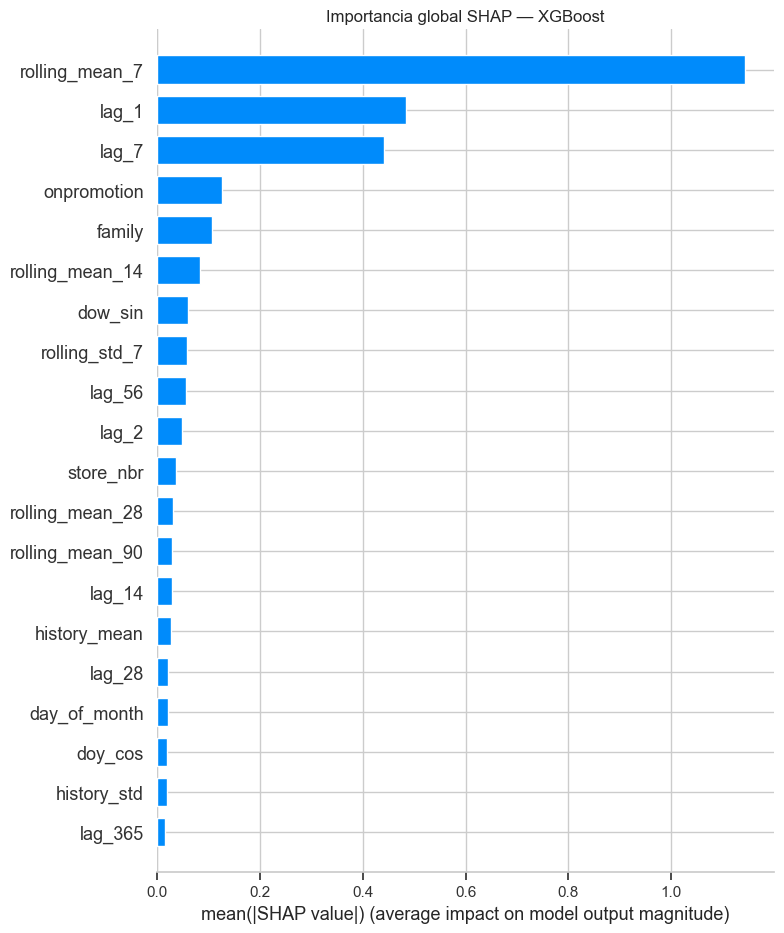

C:\Users\David\AppData\Local\Temp\ipykernel_24684\4026613711.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_plot, max_display=20, show=False)


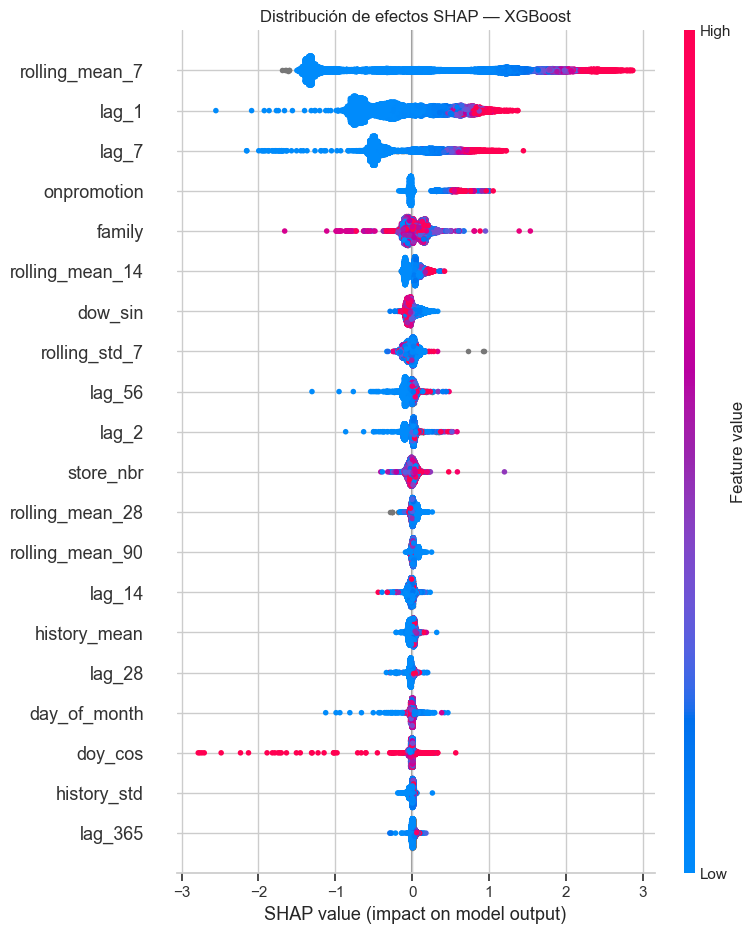

,feature,mean_abs_shap
30,rolling_mean_7,1.142683
22,lag_1,0.484633
25,lag_7,0.441658
6,onpromotion,0.126145
1,family,0.107299
31,rolling_mean_14,0.082520
13,dow_sin,0.059193
34,rolling_std_7,0.058103
28,lag_56,0.055894
23,lag_2,0.048150


In [27]:
assert RUN_MODEL_COMPARISON and not model_comparison.empty, 'Ejecuta primero la comparación de modelos.'
holdout_key = ('HOLDOUT_15d', selected_model_family)
assert holdout_key in comparison_models, f'No existe modelo de holdout para {selected_model_family}.'
interpretation_model = comparison_models[holdout_key]

shap_mask = train_featured['date'] < pd.Timestamp('2017-08-01')
shap_years = sorted(train_featured.loc[shap_mask, 'date'].dt.year.unique())
per_year = max(1, SHAP_SAMPLE_SIZE // len(shap_years))
shap_parts = []
for year in shap_years:
    year_mask = shap_mask & train_featured['date'].dt.year.eq(year)
    year_rows = train_featured.loc[year_mask]
    shap_parts.append(year_rows.sample(min(len(year_rows), per_year), random_state=SEED + int(year)))
shap_sample = pd.concat(shap_parts, ignore_index=True)
if len(shap_sample) > SHAP_SAMPLE_SIZE:
    shap_sample = shap_sample.sample(SHAP_SAMPLE_SIZE, random_state=SEED)
X_shap = prepare_X(shap_sample, FEATURE_COLS)

def calculate_tree_shap(model, X):
    try:
        values = shap.TreeExplainer(model).shap_values(X)
        return np.asarray(values)
    except Exception as exc:
        print('TreeExplainer directo no disponible; usando contribuciones nativas:', exc)
        if hasattr(model, 'get_booster'):
            matrix = xgb.DMatrix(X, enable_categorical=True)
            return model.get_booster().predict(matrix, pred_contribs=True)[:, :-1]
        return np.asarray(model.predict(X, pred_contrib=True))[:, :-1]

shap_values = calculate_tree_shap(interpretation_model, X_shap)
assert shap_values.shape == (len(X_shap), len(FEATURE_COLS))
X_shap_plot = X_shap.copy()
for col in CATEGORICAL_COLS:
    X_shap_plot[col] = X_shap_plot[col].cat.codes

shap_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)
shap_importance.to_csv(TABLE_DIR / 'shap_global_importance.csv', index=False)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_plot, plot_type='bar', max_display=20, show=False)
plt.title(f'Importancia global SHAP — {selected_model_family}')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'shap_global_bar.png', dpi=170, bbox_inches='tight')
plt.show()

plt.figure(figsize=(11, 8))
shap.summary_plot(shap_values, X_shap_plot, max_display=20, show=False)
plt.title(f'Distribución de efectos SHAP — {selected_model_family}')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'shap_global_beeswarm.png', dpi=170, bbox_inches='tight')
plt.show()
display(shap_importance.head(20))

## 12. Simulación operativa de inventario — servicio 95%

Ante la ausencia de costos económicos por SKU, se adopta un fractil crítico del 95%. Los cuantiles se calibran con residuos recursivos de B1/B2 y se evalúan una sola vez en el holdout. Los precios de USD 5–15 valoran el capital, pero no cambian las unidades de safety stock.

In [28]:
CALIBRATION_WINDOWS = ['B1_16d', 'B2_16d']
assert all((w, selected_model_family) in comparison_predictions for w in CALIBRATION_WINDOWS)
assert all((w, 'Naive') in comparison_predictions for w in CALIBRATION_WINDOWS)

def combine_actual_predictions(window, selected_model_name):
    start, end = BACKTEST_WINDOWS[window]
    actual = train_static[train_static['date'].between(start, end)][
        ['id', 'date'] + KEY_COLS + [TARGET]
    ].rename(columns={TARGET: 'sales_actual'})
    selected = comparison_predictions[(window, selected_model_name)][['id', TARGET]].rename(
        columns={TARGET: 'sales_model'}
    )
    naive = comparison_predictions[(window, 'Naive')][['id', TARGET]].rename(
        columns={TARGET: 'sales_naive'}
    )
    out = actual.merge(selected, on='id', validate='one_to_one').merge(
        naive, on='id', validate='one_to_one'
    )
    out['residual_model'] = out['sales_actual'] - out['sales_model']
    out['residual_naive'] = out['sales_actual'] - out['sales_naive']
    return out

calibration = pd.concat(
    [combine_actual_predictions(w, selected_model_family) for w in CALIBRATION_WINDOWS],
    ignore_index=True,
)

def positive_quantile(values, q=SERVICE_LEVEL):
    return float(max(0.0, pd.Series(values).quantile(q)))

ss_by_series = calibration.groupby(KEY_COLS).agg(
    n_calibration=('residual_model', 'size'),
    ss_model=('residual_model', positive_quantile),
    ss_naive=('residual_naive', positive_quantile),
).reset_index()

# Respaldo jerárquico para series con poca calibración: familia y después global.
family_fallback = calibration.groupby('family').agg(
    family_ss_model=('residual_model', positive_quantile),
    family_ss_naive=('residual_naive', positive_quantile),
).reset_index()
ss_by_series = ss_by_series.merge(family_fallback, on='family', validate='many_to_one')
low_history = ss_by_series['n_calibration'] < 20
ss_by_series.loc[low_history, 'ss_model'] = ss_by_series.loc[low_history, 'family_ss_model']
ss_by_series.loc[low_history, 'ss_naive'] = ss_by_series.loc[low_history, 'family_ss_naive']
ss_by_series['ss_reduction'] = ss_by_series['ss_naive'] - ss_by_series['ss_model']

holdout_inventory = combine_actual_predictions('HOLDOUT_15d', selected_model_family).merge(
    ss_by_series[KEY_COLS + ['ss_model', 'ss_naive']],
    on=KEY_COLS, how='left', validate='many_to_one'
)
holdout_inventory['inventory_model'] = holdout_inventory['sales_model'] + holdout_inventory['ss_model']
holdout_inventory['inventory_naive'] = holdout_inventory['sales_naive'] + holdout_inventory['ss_naive']
for model_name in ['model', 'naive']:
    inventory_col = f'inventory_{model_name}'
    holdout_inventory[f'covered_{model_name}'] = (
        holdout_inventory['sales_actual'] <= holdout_inventory[inventory_col]
    )
    holdout_inventory[f'shortage_{model_name}'] = (
        holdout_inventory['sales_actual'] - holdout_inventory[inventory_col]
    ).clip(lower=0)
    holdout_inventory[f'overage_{model_name}'] = (
        holdout_inventory[inventory_col] - holdout_inventory['sales_actual']
    ).clip(lower=0)

holdout_inventory['ae_model'] = np.abs(holdout_inventory['sales_actual'] - holdout_inventory['sales_model'])
holdout_inventory['ae_naive'] = np.abs(holdout_inventory['sales_actual'] - holdout_inventory['sales_naive'])
error_by_series = holdout_inventory.groupby(KEY_COLS).agg(
    mae_model=('ae_model', 'mean'), mae_naive=('ae_naive', 'mean'),
    service_model=('covered_model', 'mean'), service_naive=('covered_naive', 'mean'),
).reset_index().merge(
    ss_by_series[KEY_COLS + ['ss_model', 'ss_naive', 'ss_reduction']],
    on=KEY_COLS, validate='one_to_one'
)
error_by_series['mae_reduction_pct'] = (
    (error_by_series['mae_naive'] - error_by_series['mae_model'])
    / error_by_series['mae_naive'].replace(0, np.nan) * 100
).fillna(0)

total_ss_model = float(ss_by_series['ss_model'].sum())
total_ss_naive = float(ss_by_series['ss_naive'].sum())
ss_reduction_total = total_ss_naive - total_ss_model
inventory_summary = pd.DataFrame([
    {
        'model': 'Naive', 'safety_stock_units': total_ss_naive,
        'service_achieved': holdout_inventory['covered_naive'].mean(),
        'shortage_units': holdout_inventory['shortage_naive'].sum(),
        'overage_units': holdout_inventory['overage_naive'].sum(),
        'mae': holdout_inventory['ae_naive'].mean(),
    },
    {
        'model': selected_model_family, 'safety_stock_units': total_ss_model,
        'service_achieved': holdout_inventory['covered_model'].mean(),
        'shortage_units': holdout_inventory['shortage_model'].sum(),
        'overage_units': holdout_inventory['overage_model'].sum(),
        'mae': holdout_inventory['ae_model'].mean(),
    },
])

price_sensitivity = pd.DataFrame({'unit_price_usd': UNIT_PRICES})
price_sensitivity['capital_naive_usd'] = total_ss_naive * price_sensitivity['unit_price_usd']
price_sensitivity['capital_model_usd'] = total_ss_model * price_sensitivity['unit_price_usd']
price_sensitivity['capital_freed_usd'] = ss_reduction_total * price_sensitivity['unit_price_usd']
price_sensitivity['annual_holding_savings_usd'] = (
    price_sensitivity['capital_freed_usd'] * HOLDING_RATE_ANNUAL
)

family_inventory = error_by_series.groupby('family').agg(
    mae_model=('mae_model', 'mean'), mae_naive=('mae_naive', 'mean'),
    ss_model=('ss_model', 'sum'), ss_naive=('ss_naive', 'sum'),
    ss_reduction=('ss_reduction', 'sum'),
).reset_index()

ss_by_series.to_csv(TABLE_DIR / 'newsvendor_by_series.csv', index=False)
family_inventory.to_csv(TABLE_DIR / 'newsvendor_by_family.csv', index=False)
inventory_summary.to_csv(TABLE_DIR / 'operational_summary.csv', index=False)
price_sensitivity.to_csv(TABLE_DIR / 'price_sensitivity_5_15.csv', index=False)
holdout_inventory.to_parquet(PREDICTION_DIR / 'holdout_inventory_evaluation.parquet', index=False)
display(inventory_summary)
display(price_sensitivity[price_sensitivity['unit_price_usd'].isin([5, 10, 15])])
print(f'Reducción de safety stock: {ss_reduction_total:,.1f} unidades')

,model,safety_stock_units,service_achieved,shortage_units,overage_units,mae
0,Naive,321359.291489,0.919267,170465.133982,5.253322e+06,98.694989
1,XGBoost,208084.252766,0.924093,114505.480089,4.462086e+06,82.543358


,unit_price_usd,capital_naive_usd,capital_model_usd,capital_freed_usd,annual_holding_savings_usd
0,5.0,1.606796e+06,1.040421e+06,5.663752e+05,141593.798404
5,10.0,3.213593e+06,2.080843e+06,1.132750e+06,283187.596807
10,15.0,4.820389e+06,3.121264e+06,1.699126e+06,424781.395211


Reducción de safety stock: 113,275.0 unidades


## 13. Gráficos finales

Esta sección consolida los entregables visuales del holdout, la matriz de correlación, el efecto WTI, la simulación de inventario y la ventana de estrés.

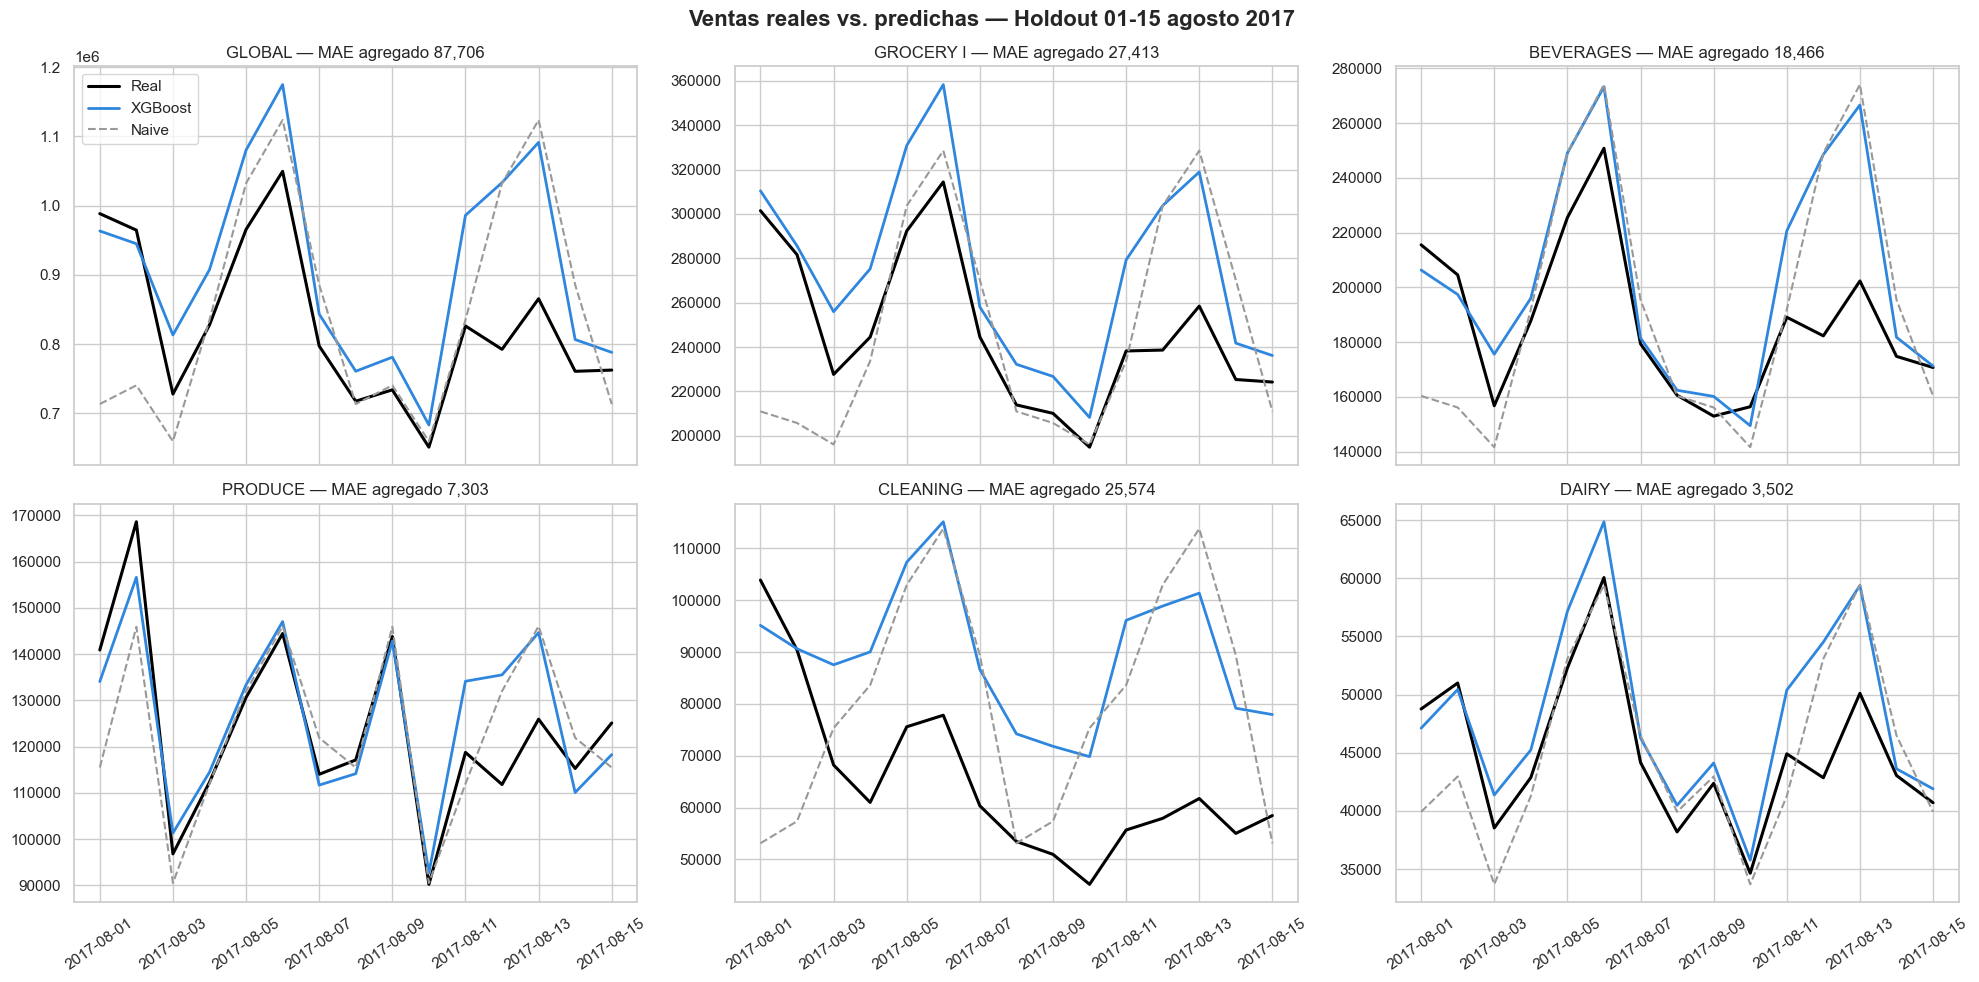

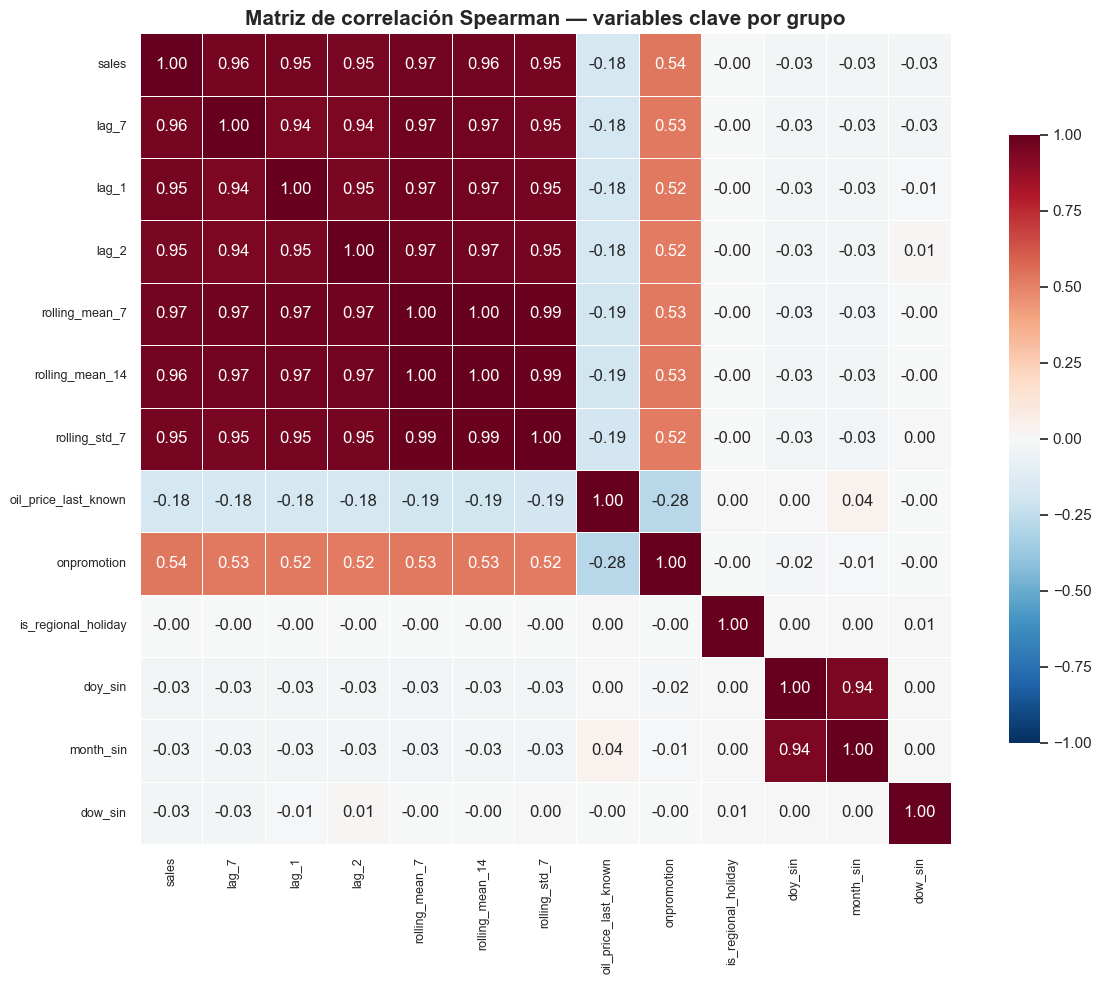

,group,feature,selection_rule,spearman_with_sales,abs_spearman_with_sales,rank_in_group
0,Rezagos,lag_7,top |Spearman| con sales,0.959588,0.959588,1
1,Rezagos,lag_1,top |Spearman| con sales,0.953373,0.953373,2
2,Rezagos,lag_2,top |Spearman| con sales,0.948370,0.948370,3
3,Ventanas e historia,rolling_mean_7,top 2 medias por |Spearman|,0.968389,0.968389,1
4,Ventanas e historia,rolling_mean_14,top 2 medias por |Spearman|,0.964499,0.964499,2
5,Ventanas e historia,rolling_std_7,top 1 volatilidad por |Spearman|,0.954862,0.954862,3
6,Exógenas y negocio,oil_price_last_known,fija: hipótesis WTI/promoción del proyecto,-0.177849,0.177849,2
7,Exógenas y negocio,onpromotion,fija: hipótesis WTI/promoción del proyecto,0.537072,0.537072,1
8,Exógenas y negocio,is_regional_holiday,mejor indicador de feriado,-0.003725,0.003725,3
9,Calendario,doy_sin,top |Spearman| con sales,-0.031049,0.031049,1


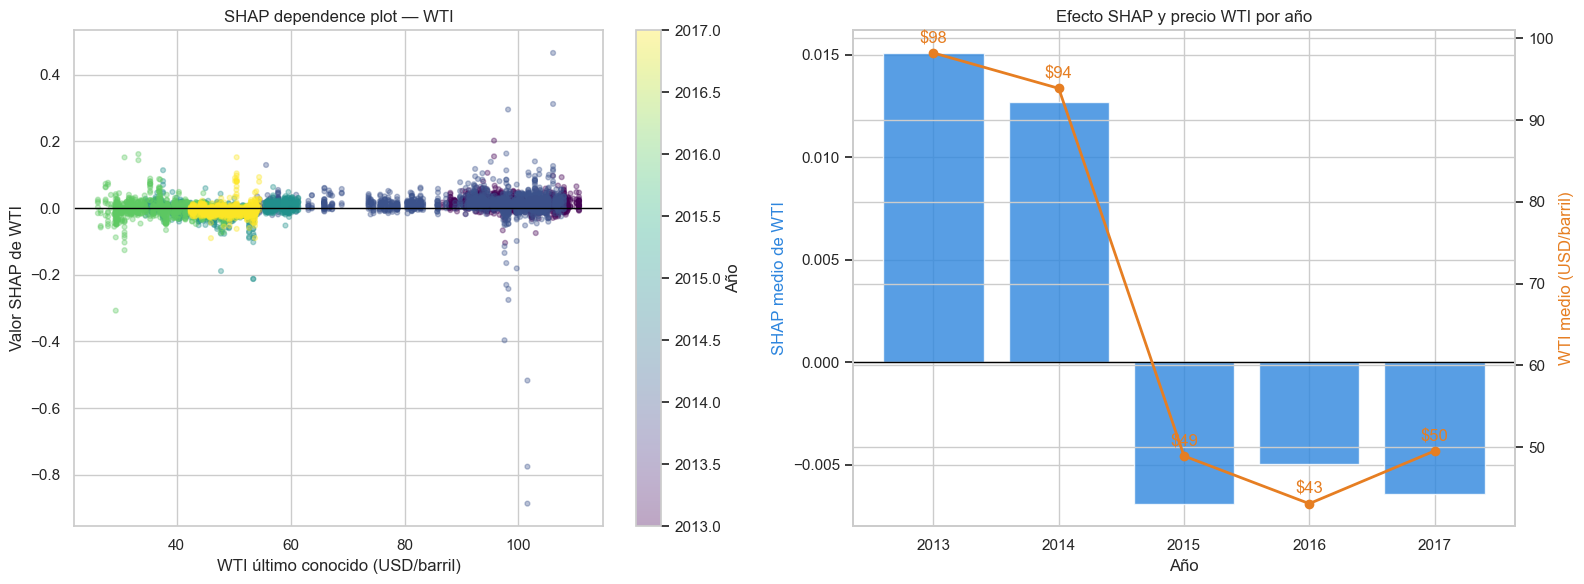

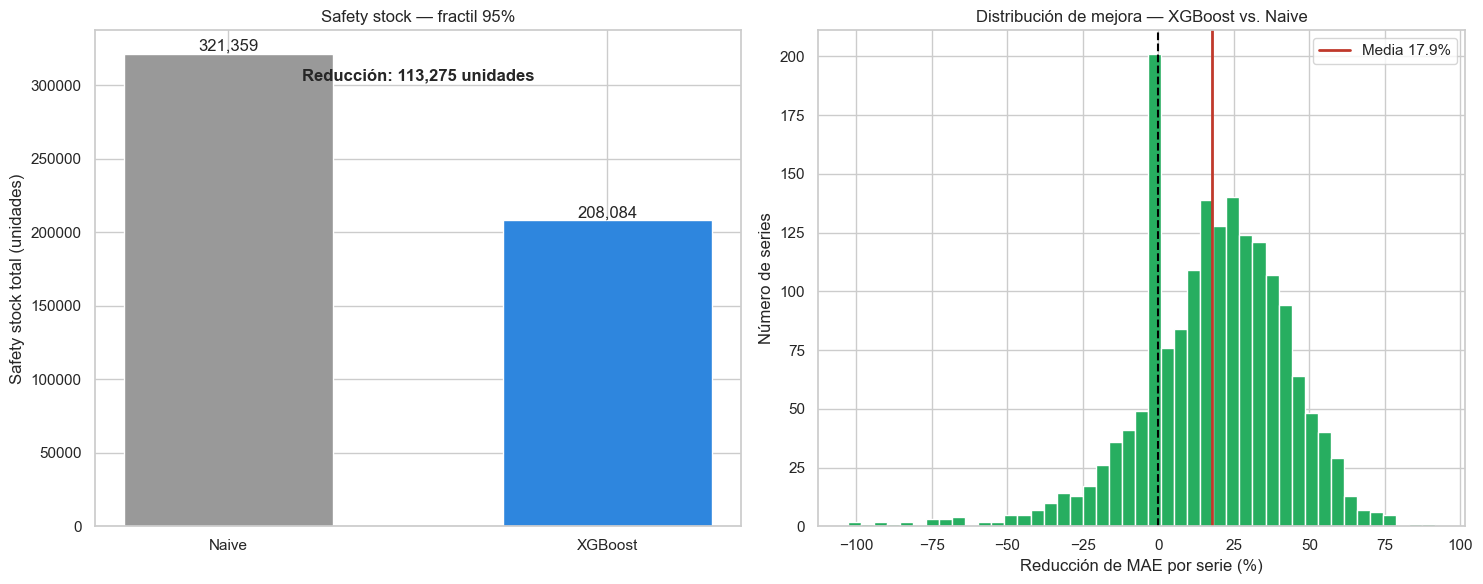

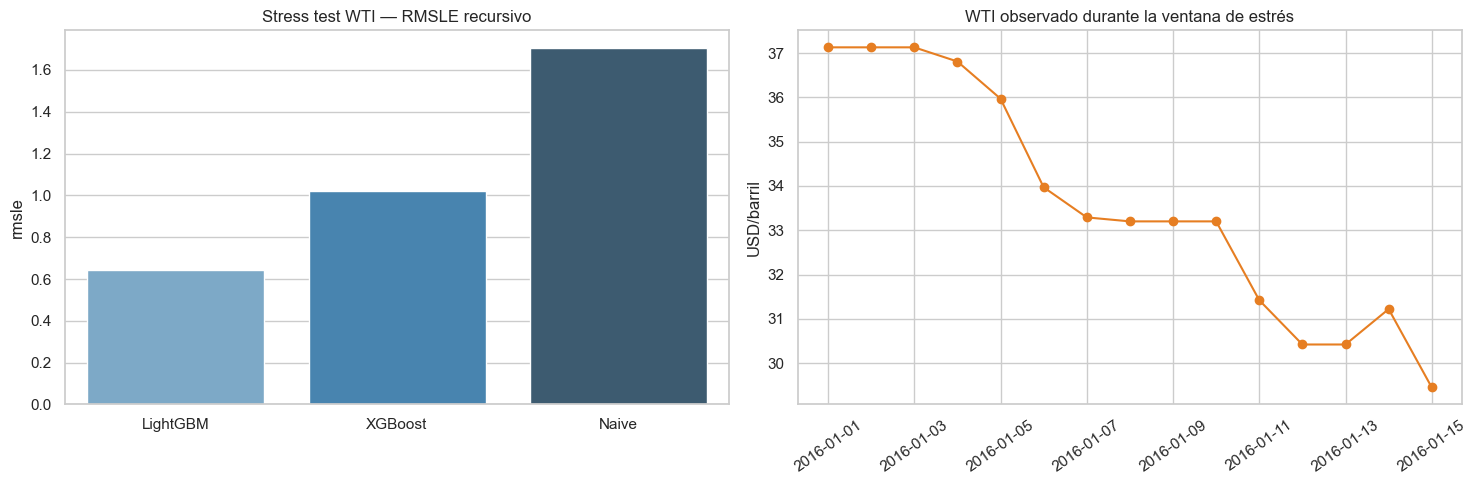

Gráficos guardados en: C:\Users\David\Documents\Capston\Outputs v3 causal two stage xgb\figures


In [29]:
sns.set_theme(style='whitegrid')

# 1) Ventas reales vs. predichas: global + top 5 familias históricas.
top5_families = (
    train_static[train_static['date'] < pd.Timestamp('2017-08-01')]
    .groupby('family')[TARGET].sum().nlargest(5).index.tolist()
)
panels = [('GLOBAL', None)] + [(family, family) for family in top5_families]
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True)
for ax, (label, family) in zip(axes.flat, panels):
    data = holdout_inventory if family is None else holdout_inventory[holdout_inventory['family'] == family]
    daily = data.groupby('date', as_index=False).agg(
        real=('sales_actual', 'sum'), model=('sales_model', 'sum'), naive=('sales_naive', 'sum')
    )
    ax.plot(daily['date'], daily['real'], color='black', linewidth=2.2, label='Real')
    ax.plot(daily['date'], daily['model'], color='#2E86DE', linewidth=2, label=selected_model_family)
    ax.plot(daily['date'], daily['naive'], color='#999999', linestyle='--', linewidth=1.5, label='Naive')
    panel_mae = mean_absolute_error(daily['real'], daily['model'])
    ax.set_title(f'{label} — MAE agregado {panel_mae:,.0f}')
    ax.tick_params(axis='x', rotation=35)
axes.flat[0].legend()
fig.suptitle('Ventas reales vs. predichas — Holdout 01-15 agosto 2017', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'actual_vs_predicted_holdout.png', dpi=170, bbox_inches='tight')
plt.show()

# 2) Matriz Spearman compacta: 12 variables clave por grupo, evaluadas solo en train.
# No se incluyen códigos de family/type/city/state: su orden numérico sería arbitrario.
CORR_GROUPS = {
    'Rezagos': [c for c in FEATURE_COLS if c.startswith('lag_')],
    'Medias móviles': [c for c in FEATURE_COLS if c.startswith('rolling_mean_')],
    'Volatilidad móvil': [c for c in FEATURE_COLS if c.startswith('rolling_std_')],
    'Feriados': [
        'is_national_holiday', 'is_regional_holiday', 'is_local_holiday',
        'is_extra_workday', 'is_holiday'
    ],
    'Calendario': [
        'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos',
        'day_of_month', 'is_month_start', 'is_month_end'
    ],
}
FIXED_CORR_FEATURES = ['oil_price_last_known', 'onpromotion']
corr_candidates = list(dict.fromkeys(
    FIXED_CORR_FEATURES + [c for cols in CORR_GROUPS.values() for c in cols]
))
corr_sample = (
    train_featured.sample(min(CORR_SAMPLE_SIZE, len(train_featured)), random_state=SEED)
    [[TARGET] + corr_candidates].copy()
)
target_corr = corr_sample.corr(method='spearman')[TARGET].drop(TARGET)
selected_corr_rows = []
def add_top_corr(group, candidates, top_n, rule='top |Spearman| con sales'):
    ranked = target_corr.reindex(candidates).dropna().abs().sort_values(ascending=False)
    for feature in ranked.head(top_n).index:
        selected_corr_rows.append({
            'group': group, 'feature': feature, 'selection_rule': rule,
            'spearman_with_sales': target_corr[feature],
            'abs_spearman_with_sales': abs(target_corr[feature]),
        })

add_top_corr('Rezagos', CORR_GROUPS['Rezagos'], 3)
add_top_corr('Ventanas e historia', CORR_GROUPS['Medias móviles'], 2, 'top 2 medias por |Spearman|')
add_top_corr('Ventanas e historia', CORR_GROUPS['Volatilidad móvil'], 1, 'top 1 volatilidad por |Spearman|')
for feature in FIXED_CORR_FEATURES:
    selected_corr_rows.append({
        'group': 'Exógenas y negocio', 'feature': feature,
        'selection_rule': 'fija: hipótesis WTI/promoción del proyecto',
        'spearman_with_sales': target_corr[feature],
        'abs_spearman_with_sales': abs(target_corr[feature]),
    })
add_top_corr('Exógenas y negocio', CORR_GROUPS['Feriados'], 1, 'mejor indicador de feriado')
add_top_corr('Calendario', CORR_GROUPS['Calendario'], 3)
corr_selection = pd.DataFrame(selected_corr_rows)
corr_selection['rank_in_group'] = (
    corr_selection.groupby('group')['abs_spearman_with_sales']
    .rank(method='first', ascending=False).astype(int)
)
selected_corr_features = corr_selection['feature'].tolist()
corr_matrix = corr_sample[[TARGET] + selected_corr_features].corr(method='spearman')

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4, cbar_kws={'shrink': 0.75}
)
plt.title('Matriz de correlación Spearman — variables clave por grupo', fontsize=15, fontweight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'correlation_matrix_key_features.png', dpi=180, bbox_inches='tight')
plt.show()
corr_matrix.to_csv(TABLE_DIR / 'correlation_matrix_key_features.csv')
corr_selection.to_csv(TABLE_DIR / 'correlation_features_selected.csv', index=False)
display(corr_selection)

# 3) Efecto WTI: dependencia SHAP y agregación anual con etiqueta de precio.
oil_idx = FEATURE_COLS.index('oil_price_last_known')
wti_effect = pd.DataFrame({
    'date': shap_sample['date'].to_numpy(),
    'year': shap_sample['date'].dt.year.to_numpy(),
    'oil_price': shap_sample['oil_price_last_known'].to_numpy(),
    'shap_wti': shap_values[:, oil_idx],
}).dropna()
yearly_wti = wti_effect.groupby('year', as_index=False).agg(
    mean_shap_wti=('shap_wti', 'mean'), mean_oil_price=('oil_price', 'mean')
)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scatter = axes[0].scatter(
    wti_effect['oil_price'], wti_effect['shap_wti'], c=wti_effect['year'],
    cmap='viridis', alpha=0.35, s=12
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('WTI último conocido (USD/barril)')
axes[0].set_ylabel('Valor SHAP de WTI')
axes[0].set_title('SHAP dependence plot — WTI')
fig.colorbar(scatter, ax=axes[0], label='Año')
axes[1].bar(yearly_wti['year'], yearly_wti['mean_shap_wti'], color='#2E86DE', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Año')
axes[1].set_ylabel('SHAP medio de WTI', color='#2E86DE')
oil_axis = axes[1].twinx()
oil_axis.plot(yearly_wti['year'], yearly_wti['mean_oil_price'], color='#E67E22', marker='o', linewidth=2)
oil_axis.set_ylabel('WTI medio (USD/barril)', color='#E67E22')
for _, row in yearly_wti.iterrows():
    oil_axis.annotate(f"${row['mean_oil_price']:.0f}", (row['year'], row['mean_oil_price']),
                      textcoords='offset points', xytext=(0, 7), ha='center', color='#E67E22')
axes[1].set_title('Efecto SHAP y precio WTI por año')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'shap_wti_effect.png', dpi=170, bbox_inches='tight')
plt.show()
wti_effect.to_csv(TABLE_DIR / 'shap_wti_observations.csv', index=False)

# 4) Safety stock y distribución de mejora de MAE frente a Naive.
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars = axes[0].bar(
    ['Naive', selected_model_family], [total_ss_naive, total_ss_model],
    color=['#999999', '#2E86DE'], width=0.55
)
for bar, value in zip(bars, [total_ss_naive, total_ss_model]):
    axes[0].text(bar.get_x() + bar.get_width()/2, value, f'{value:,.0f}', ha='center', va='bottom')
axes[0].set_ylabel('Safety stock total (unidades)')
axes[0].set_title(f'Safety stock — fractil {SERVICE_LEVEL:.0%}')
axes[0].text(0.5, 0.90, f'Reducción: {ss_reduction_total:,.0f} unidades',
             transform=axes[0].transAxes, ha='center', fontweight='bold')
axes[1].hist(error_by_series['mae_reduction_pct'], bins=45, color='#27AE60', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].axvline(error_by_series['mae_reduction_pct'].mean(), color='#C0392B', linewidth=2,
                label=f"Media {error_by_series['mae_reduction_pct'].mean():.1f}%")
axes[1].set_xlabel('Reducción de MAE por serie (%)')
axes[1].set_ylabel('Número de series')
axes[1].set_title(f'Distribución de mejora — {selected_model_family} vs. Naive')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'safety_stock_and_mae_improvement.png', dpi=170, bbox_inches='tight')
plt.show()

# 5) Stress test y trayectoria observada del WTI (esta última es solo contexto diagnóstico).
stress_metrics = model_comparison[model_comparison['window'] == 'STRESS_WTI_15d'].sort_values('rmsle')
stress_oil = oil_daily[oil_daily['date'].between('2016-01-01', '2016-01-15')]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=stress_metrics, x='model', y='rmsle', hue='model', ax=axes[0],
            palette='Blues_d', legend=False)
axes[0].set_title('Stress test WTI — RMSLE recursivo')
axes[0].set_xlabel('')
axes[1].plot(stress_oil['date'], stress_oil['oil_price_observed'], color='#E67E22', marker='o')
axes[1].set_title('WTI observado durante la ventana de estrés')
axes[1].set_ylabel('USD/barril')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'stress_wti_comparison.png', dpi=170, bbox_inches='tight')
plt.show()

print('Gráficos guardados en:', FIGURE_DIR)

## 14. Persistencia y auditoría final

In [30]:
train_featured.to_parquet(OUTPUT_DIR / 'train_featured_v3.parquet', index=False)
test_static.to_parquet(OUTPUT_DIR / 'test_static_v3.parquet', index=False)

metadata = {
    'seed': SEED,
    'train_rows': int(len(train_featured)),
    'test_rows': int(len(test_static)),
    'n_series': int(N_SERIES),
    'features': FEATURE_COLS,
    'categorical_levels': {
        col: [value.item() if hasattr(value, 'item') else value for value in levels]
        for col, levels in CATEGORY_LEVELS.items()
    },
    'selected_model_family': selected_model_family,
    'family_selection_method': 'base_vs_base_mean_rmsle_on_B1_B2',
    'family_selection_windows': FAMILY_SELECTION_WINDOWS,
    'family_selection_summary': family_selection_summary.to_dict(orient='records'),
    'selected_xgb_config': selected_xgb_config if selected_model_family == 'XGBoost' else None,
    'xgb_tuning_executed': bool(xgb_tuning_executed),
    'xgb_tuning_reused': bool(xgb_tuning_reused),
    'xgb_tuning_cache_dir': str(TUNING_CACHE_DIR) if xgb_tuning_reused else None,
    'lgb_tuning_executed': bool(lgb_tuning_executed),
    'model_params': final_model_params,
    'xgb_default_params': DEFAULT_PARAMS,
    'xgb_tuned_params': tuned_params if (xgb_tuning_executed or xgb_tuning_reused) else None,
    'future_oil_policy': 'freeze_at_last_observed_before_forecast_origin',
    'transactions_used': False,
    'forecast_strategy': 'recursive',
    'baseline': 'seasonal_naive_recursive_lag_7',
    'service_level': SERVICE_LEVEL,
    'unit_price_range_usd': [float(UNIT_PRICES.min()), float(UNIT_PRICES.max())],
    'holding_rate_annual': HOLDING_RATE_ANNUAL,
    'stress_window': BACKTEST_WINDOWS['STRESS_WTI_15d'],
}
with open(OUTPUT_DIR / 'pipeline_metadata.json', 'w', encoding='utf-8') as fh:
    json.dump(metadata, fh, indent=2, ensure_ascii=False)

audit = {
    'train_id_unique': bool(train_featured['id'].is_unique),
    'test_id_unique': bool(test_static['id'].is_unique),
    'train_rows_unchanged': bool(len(train_featured) == len(train_raw)),
    'test_rows_unchanged': bool(len(test_static) == len(test_raw)),
    'transactions_excluded': bool('transactions' not in FEATURE_COLS),
    'future_oil_excluded': bool('oil_price_observed' not in FEATURE_COLS),
    'target_excluded': bool(TARGET not in FEATURE_COLS),
    'naive_holdout_available': bool(('HOLDOUT_15d', 'Naive') in comparison_predictions),
    'stress_predictions_available': bool(
        all(('STRESS_WTI_15d', model) in comparison_predictions
            for model in ['Naive', 'XGBoost', 'LightGBM'])
    ),
    'service_level_valid': bool(0 < SERVICE_LEVEL < 1),
}
assert all(audit.values())
print(json.dumps(audit, indent=2, ensure_ascii=False))
print('Pipeline finalizado sin violaciones de los contratos definidos.')

{
  "train_id_unique": true,
  "test_id_unique": true,
  "train_rows_unchanged": true,
  "test_rows_unchanged": true,
  "transactions_excluded": true,
  "future_oil_excluded": true,
  "target_excluded": true,
  "naive_holdout_available": true,
  "stress_predictions_available": true,
  "service_level_valid": true
}
Pipeline finalizado sin violaciones de los contratos definidos.


In [31]:
start_date = test_raw["date"].min()
end_date = test_raw["date"].max()

contexto_test = static_context[
    static_context["date"].between(start_date, end_date)
].copy()

print("Periodo:", contexto_test["date"].min(), "→", contexto_test["date"].max())
print("Filas:", len(contexto_test))
print("Días:", contexto_test["date"].nunique())
print("Series:", contexto_test[KEY_COLS].drop_duplicates().shape[0])

display(contexto_test.head())

Periodo: 2017-08-16 00:00:00 → 2017-08-31 00:00:00
Filas: 28512
Días: 16
Series: 1782


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,oil_price_observed,oil_price_last_known,is_national_holiday,is_regional_holiday,is_local_holiday,is_extra_workday,is_holiday,dow_sin,dow_cos,doy_sin,doy_cos,month_sin,month_cos,day_of_month,is_month_start,is_month_end
3000888,3000888,2017-08-16,1,AUTOMOTIVE,NaN,0,Quito,Pichincha,D,13,46.8,47.57,0,0,0,0,0,0.974928,-0.222521,-0.691351,-0.722519,-0.5,-0.866025,16,0,0
3000889,3000889,2017-08-16,1,BABY CARE,NaN,0,Quito,Pichincha,D,13,46.8,47.57,0,0,0,0,0,0.974928,-0.222521,-0.691351,-0.722519,-0.5,-0.866025,16,0,0
3000890,3000890,2017-08-16,1,BEAUTY,NaN,2,Quito,Pichincha,D,13,46.8,47.57,0,0,0,0,0,0.974928,-0.222521,-0.691351,-0.722519,-0.5,-0.866025,16,0,0
3000891,3000891,2017-08-16,1,BEVERAGES,NaN,20,Quito,Pichincha,D,13,46.8,47.57,0,0,0,0,0,0.974928,-0.222521,-0.691351,-0.722519,-0.5,-0.866025,16,0,0
3000892,3000892,2017-08-16,1,BOOKS,NaN,0,Quito,Pichincha,D,13,46.8,47.57,0,0,0,0,0,0.974928,-0.222521,-0.691351,-0.722519,-0.5,-0.866025,16,0,0


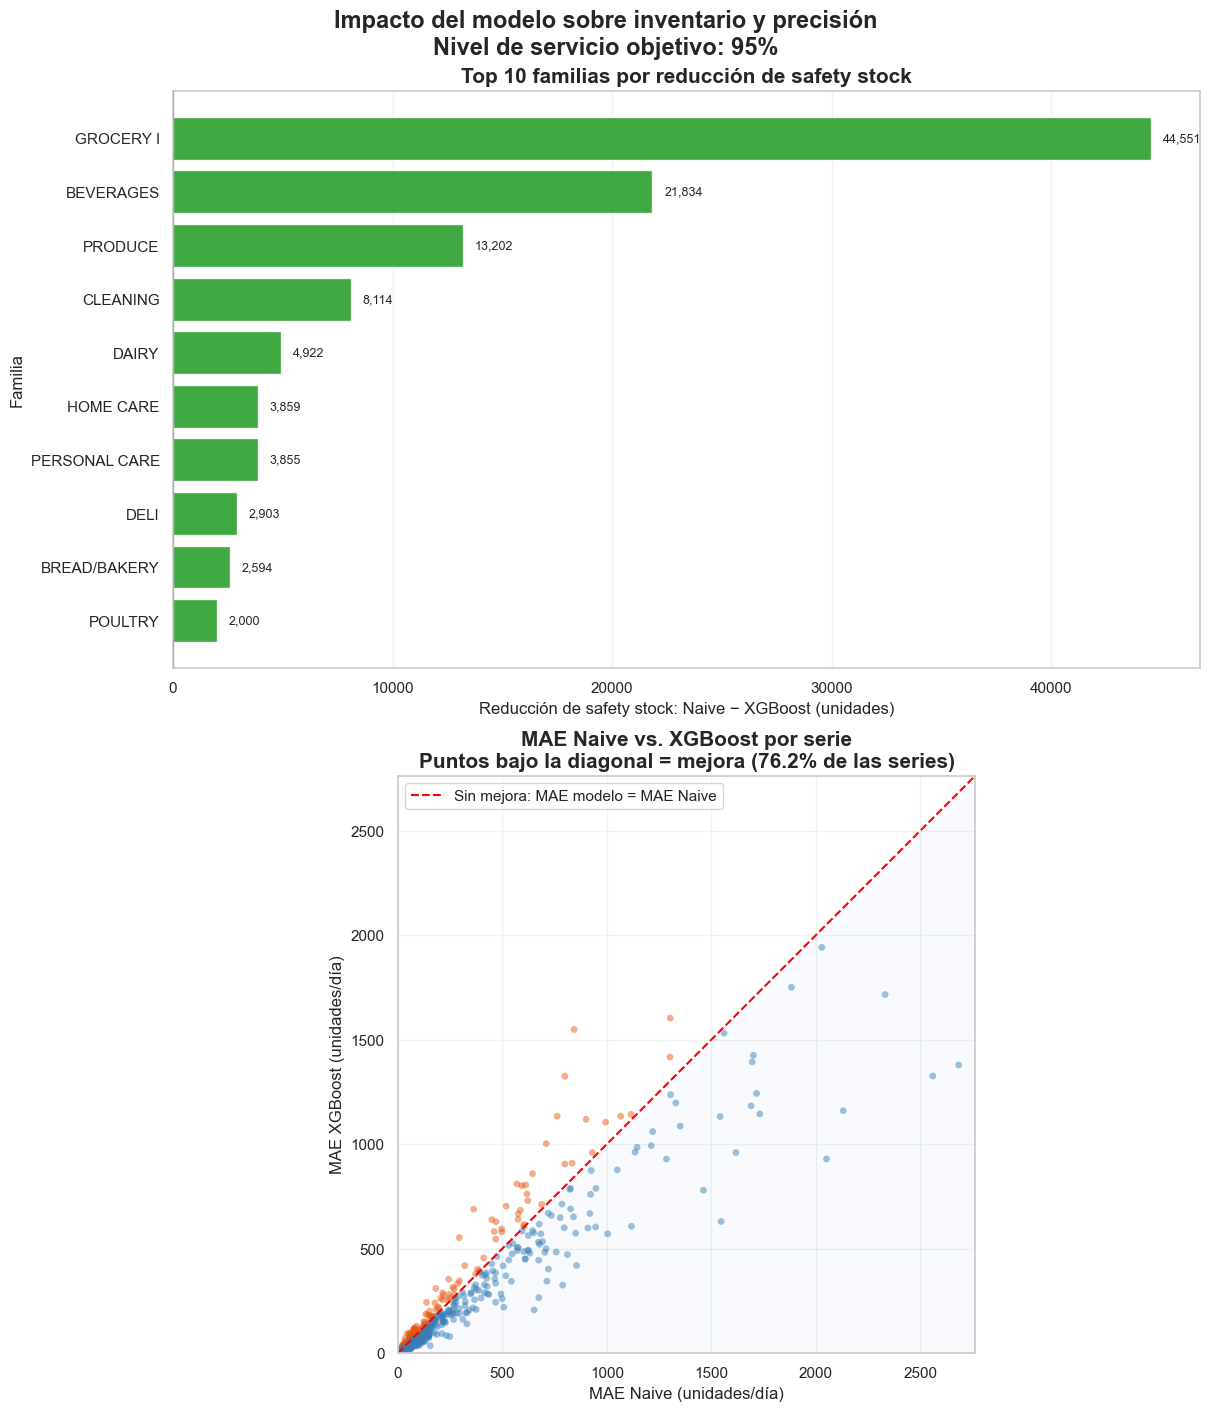

Gráfico guardado en: C:\Users\David\Documents\Capston\Outputs v3 causal two stage xgb\figures\safety_stock_top10_families_and_mae_by_series.png
Series evaluadas: 1,782
Series donde XGBoost mejora a Naive: 1,357 (76.15%)


,family,ss_naive,ss_model,ss_reduction
12,GROCERY I,86956.833346,42406.124210,44550.709136
3,BEVERAGES,75023.800000,53189.965634,21833.834366
30,PRODUCE,23667.586044,10465.465685,13202.120359
7,CLEANING,56394.450000,48279.998436,8114.451564
8,DAIRY,10381.950000,5459.598511,4922.351489
18,HOME CARE,8444.050000,4584.561526,3859.488474
25,PERSONAL CARE,9822.800000,5967.583807,3855.216193
9,DELI,6284.528701,3381.570051,2902.958649
5,BREAD/BAKERY,6845.562718,4251.597432,2593.965286
28,POULTRY,6846.668923,4846.557367,2000.111556


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Validaciones
required_family_cols = {
    'family', 'ss_model', 'ss_naive', 'ss_reduction'
}
required_series_cols = {
    'family', 'mae_model', 'mae_naive', 'ss_reduction'
}

assert required_family_cols.issubset(family_inventory.columns), (
    f'Faltan columnas en family_inventory: '
    f'{required_family_cols - set(family_inventory.columns)}'
)
assert required_series_cols.issubset(error_by_series.columns), (
    f'Faltan columnas en error_by_series: '
    f'{required_series_cols - set(error_by_series.columns)}'
)

model_label = (
    selected_model_family
    if 'selected_model_family' in globals()
    else 'XGBoost'
)

# ============================================================
# 1. Top 10 familias por reducción del safety stock
# ============================================================

top10_ss = (
    family_inventory
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=['ss_reduction'])
    .sort_values('ss_reduction', ascending=False)
    .head(10)
    .sort_values('ss_reduction', ascending=True)
    .copy()
)

# ============================================================
# 2. MAE Naive vs. modelo seleccionado por serie
# ============================================================

scatter_data = (
    error_by_series
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=['mae_naive', 'mae_model'])
    .copy()
)

scatter_data['improves'] = (
    scatter_data['mae_model'] < scatter_data['mae_naive']
)

n_series = len(scatter_data)
n_improves = int(scatter_data['improves'].sum())
improvement_pct = 100 * n_improves / n_series

# Límite común para que la diagonal represente y = x
axis_max = max(
    scatter_data['mae_naive'].max(),
    scatter_data['mae_model'].max()
)
axis_max *= 1.03

# ============================================================
# Gráfico conjunto
# ============================================================

sns.set_theme(style='whitegrid', context='notebook')

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 14),
    constrained_layout=True
)

# ---------- Panel A: Safety stock ----------
bar_colors = [
    '#2ca02c' if value >= 0 else '#d62728'
    for value in top10_ss['ss_reduction']
]

bars = axes[0].barh(
    top10_ss['family'].astype(str),
    top10_ss['ss_reduction'],
    color=bar_colors,
    alpha=0.90
)

axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title(
    'Top 10 familias por reducción de safety stock',
    fontsize=15,
    fontweight='bold'
)
axes[0].set_xlabel(
    f'Reducción de safety stock: Naive − {model_label} (unidades)'
)
axes[0].set_ylabel('Familia')
axes[0].grid(axis='x', alpha=0.25)
axes[0].grid(axis='y', visible=False)

# Etiquetas al final de las barras
max_reduction = max(abs(top10_ss['ss_reduction']).max(), 1)

for bar, value in zip(bars, top10_ss['ss_reduction']):
    offset = max_reduction * 0.012

    axes[0].text(
        value + offset if value >= 0 else value - offset,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        va='center',
        ha='left' if value >= 0 else 'right',
        fontsize=9
    )

# ---------- Panel B: MAE por serie ----------
sns.scatterplot(
    data=scatter_data,
    x='mae_naive',
    y='mae_model',
    hue='improves',
    palette={
        True: '#377eb8',
        False: '#e6550d'
    },
    alpha=0.48,
    s=24,
    linewidth=0,
    ax=axes[1],
    legend=False
)

axes[1].plot(
    [0, axis_max],
    [0, axis_max],
    linestyle='--',
    color='red',
    linewidth=1.5,
    label='Sin mejora: MAE modelo = MAE Naive'
)

axes[1].fill_between(
    [0, axis_max],
    [0, axis_max],
    [0, 0],
    color='#377eb8',
    alpha=0.04
)

axes[1].set_xlim(0, axis_max)
axes[1].set_ylim(0, axis_max)
axes[1].set_aspect('equal', adjustable='box')

axes[1].set_title(
    f'MAE Naive vs. {model_label} por serie\n'
    f'Puntos bajo la diagonal = mejora ({improvement_pct:.1f}% de las series)',
    fontsize=15,
    fontweight='bold'
)
axes[1].set_xlabel('MAE Naive (unidades/día)')
axes[1].set_ylabel(f'MAE {model_label} (unidades/día)')
axes[1].legend(loc='upper left', frameon=True)
axes[1].grid(alpha=0.25)

fig.suptitle(
    f'Impacto del modelo sobre inventario y precisión\n'
    f'Nivel de servicio objetivo: {SERVICE_LEVEL:.0%}',
    fontsize=17,
    fontweight='bold'
)

# Guardar y mostrar
output_path = (
    FIGURE_DIR /
    'safety_stock_top10_families_and_mae_by_series.png'
)

plt.savefig(
    output_path,
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print('Gráfico guardado en:', output_path)
print(f'Series evaluadas: {n_series:,}')
print(
    f'Series donde {model_label} mejora a Naive: '
    f'{n_improves:,} ({improvement_pct:.2f}%)'
)

display(
    top10_ss[
        ['family', 'ss_naive', 'ss_model', 'ss_reduction']
    ].sort_values('ss_reduction', ascending=False)
)